## Importing Libraries

In [2]:
import os
import cv2
import glob
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from PIL import Image
import torch
from torch.utils.data import Dataset, DataLoader
import torchvision.transforms as transforms
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision.models import densenet121, DenseNet121_Weights
from tqdm import tqdm
from torchvision.datasets import ImageFolder

from sklearn.metrics import classification_report, confusion_matrix
import copy

## Phase 1: Exploratory Data Analysis (EDA)

In [1]:
# Define base paths (Adjust these to your local paths)
CXR_KANO_DIR = "/kaggle/input/datasets/spark2026nc/cxr-kano/cxr-kano"
NIAID_CXR_DIR = "/kaggle/input/datasets/spark2026nc/niaid-cxr/niaid-cxr"

def perform_eda():
    print("="*50)
    print("RUNNING EXPLORATORY DATA ANALYSIS (EDA)")
    print("="*50)
    
    # --- 1. Inspect niaid-cxr (Auxiliary Pretraining Dataset) ---
    niaid_normal = len(glob.glob(os.path.join(NIAID_CXR_DIR, "Normal", "*.png")))
    niaid_tb = len(glob.glob(os.path.join(NIAID_CXR_DIR, "Tuberculosis", "*.png")))
    
    print(f"\n[Auxiliary Dataset] NIAID-CXR Distribution:")
    print(f"  - Normal Images: {niaid_normal}")
    print(f"  - Tuberculosis Images: {niaid_tb}")
    print(f"  - Total Pretraining Images: {niaid_normal + niaid_tb}")
    
    # --- 2. Inspect cxr-kano (Fine-tuning Dataset) ---
    kano_classes = ["COVID", "NORMAL", "PNEUMONIA", "TB"]
    
    for split in ["train_folder", "test_folder"]:
        print(f"\n[Main Dataset] cxr-kano - {split} Distribution:")
        total_split = 0
        for cls in kano_classes:
            cls_path = os.path.join(CXR_KANO_DIR, split, cls, "*.png")
            count = len(glob.glob(cls_path))
            total_split += count
            print(f"  - {cls}: {count} images")
        print(f"  - Total {split}: {total_split} images")

    # --- 3. Verify Image Dimension and Channels ---
    # Sampling one image from NIAID to check properties
    sample_path = glob.glob(os.path.join(NIAID_CXR_DIR, "Normal", "*.png"))[0]
    with Image.open(sample_path) as img:
        img_np = np.array(img)
        print(f"\n[Image Properties Check]:")
        print(f"  - Sample Resolution: {img.size} (Width x Height)")
        print(f"  - Image Mode: {img.mode} (e.g., L for Grayscale, RGB for Color)")
        print(f"  - Pixel Value Range: Min={img_np.min()}, Max={img_np.max()}")

if __name__ == "__main__":
    # Ensure directories exist before running
    if os.path.exists(CXR_KANO_DIR) and os.path.exists(NIAID_CXR_DIR):
        perform_eda()
    else:
        print(" Error: Please verify your CXR_KANO_DIR and NIAID_CXR_DIR path variables.")

📊 RUNNING EXPLORATORY DATA ANALYSIS (EDA)

[Auxiliary Dataset] NIAID-CXR Distribution:
  - Normal Images: 3500
  - Tuberculosis Images: 700
  - Total Pretraining Images: 4200

[Main Dataset] cxr-kano - train_folder Distribution:
  - COVID: 500 images
  - NORMAL: 500 images
  - PNEUMONIA: 500 images
  - TB: 500 images
  - Total train_folder: 2000 images

[Main Dataset] cxr-kano - test_folder Distribution:
  - COVID: 150 images
  - NORMAL: 150 images
  - PNEUMONIA: 150 images
  - TB: 150 images
  - Total test_folder: 600 images

[Image Properties Check]:
  - Sample Resolution: (512, 512) (Width x Height)
  - Image Mode: RGB (e.g., L for Grayscale, RGB for Color)
  - Pixel Value Range: Min=0, Max=248


## Custom PyTorch Dataset Blueprint

In [2]:
class NiaidPretrainDataset(Dataset):
    """Custom Dataset class for parsing the raw flat structure of NIAID-CXR."""
    def __init__(self, base_dir, split="train", split_ratio=0.8, transform=None, seed=42):
        self.base_dir = base_dir
        self.transform = transform
        
        # Collect paths and assign binary labels: Normal=0, Tuberculosis=1
        self.image_data = []
        
        for label_idx, class_name in enumerate(["Normal", "Tuberculosis"]):
            class_folder = os.path.join(base_dir, class_name)
            images = sorted(glob.glob(os.path.join(class_folder, "*.png")))
            
            for img_path in images:
                self.image_data.append((img_path, label_idx))
        
        # Reproducible 80/20 splitting
        np.random.seed(seed)
        np.random.shuffle(self.image_data)
        
        split_point = int(len(self.image_data) * split_ratio)
        if split == "train":
            self.image_data = self.image_data[:split_point]
        else:
            self.image_data = self.image_data[split_point:]

    def __len__(self):
        return len(self.image_data)

    def __getitem__(self, idx):
        img_path, label = self.image_data[idx]
        # Force convert to RGB to match DenseNet expectation
        image = Image.open(img_path).convert("RGB") 
        
        if self.transform:
            image = self.transform(image)
            
        return image, torch.tensor(label, dtype=torch.long)

## DenseNet121 Binary Pretraining Implementation

In [4]:
# --- 1. Data Transformations ---
# DenseNet121 expects 224x224 inputs normalized with ImageNet stats
train_transforms = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomRotation(degrees=15),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

val_transforms = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

# --- 2. Instantiate Datasets & Loaders ---
# (Using the NiaidPretrainDataset class defined in our previous step)
NIAID_CXR_DIR = "/kaggle/input/datasets/spark2026nc/niaid-cxr/niaid-cxr"

train_dataset = NiaidPretrainDataset(NIAID_CXR_DIR, split="train", split_ratio=0.8, transform=train_transforms)
val_dataset = NiaidPretrainDataset(NIAID_CXR_DIR, split="val", split_ratio=0.8, transform=val_transforms)

train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True, num_workers=4, pin_memory=True)
val_loader = DataLoader(val_dataset, batch_size=32, shuffle=False, num_workers=4, pin_memory=True)

# --- 3. Set Up Model and Balanced Loss ---
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Load DenseNet121 with standard ImageNet initialization weights
model = densenet121(weights=DenseNet121_Weights.DEFAULT)

# Modify the final classification layer (classifier) for binary output (Normal vs TB)
num_ftrs = model.classifier.in_features
model.classifier = nn.Linear(num_ftrs, 2)
model = model.to(device)

# Define our calculated imbalance weights from the EDA numbers
loss_weights = torch.tensor([0.6, 3.0], dtype=torch.float).to(device)
criterion = nn.CrossEntropyLoss(weight=loss_weights)

optimizer = optim.AdamW(model.parameters(), lr=1e-4, weight_decay=1e-2)
scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=10)

# --- 4. Pretraining Loop Engine ---
def pretrain_model(epochs=10):
    print(f"Starting Binary Pretraining on {device}...")
    best_val_loss = float('inf')
    
    for epoch in range(epochs):
        model.train()
        running_loss = 0.0
        correct = 0
        total = 0
        
        # Training Phase
        for images, labels in tqdm(train_loader, desc=f"Epoch {epoch+1}/{epochs} [Train]"):
            images, labels = images.to(device), labels.to(device)
            
            optimizer.zero_grad()
            outputs = model(images)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()
            
            running_loss += loss.item() * images.size(0)
            _, predicted = outputs.max(1)
            total += labels.size(0)
            correct += predicted.eq(labels).sum().item()
            
        scheduler.step()
        epoch_train_loss = running_loss / total
        epoch_train_acc = (correct / total) * 100
        
        # Validation Phase
        model.eval()
        val_loss = 0.0
        val_correct = 0
        val_total = 0
        
        with torch.no_grad():
            for images, labels in val_loader:
                images, labels = images.to(device), labels.to(device)
                outputs = model(images)
                loss = criterion(outputs, labels)
                
                val_loss += loss.item() * images.size(0)
                _, predicted = outputs.max(1)
                val_total += labels.size(0)
                val_correct += predicted.eq(labels).sum().item()
        
        epoch_val_loss = val_loss / val_total
        epoch_val_acc = (val_correct / val_total) * 100
        
        print(f"📊 Epoch {epoch+1}: Train Loss: {epoch_train_loss:.4f} | Train Acc: {epoch_train_acc:.2f}% | Val Loss: {epoch_val_loss:.4f} | Val Acc: {epoch_val_acc:.2f}%")
        
        # Save Best Weights checkpoint securely
        if epoch_val_loss < best_val_loss:
            best_val_loss = epoch_val_loss
            torch.save(model.state_dict(), "tb_pretrained_backbone.pth")
            print("💾 Saved new best pretraining weights checkpoint to 'tb_pretrained_backbone.pth'")

if __name__ == "__main__":
    pretrain_model(epochs=10)

Downloading: "https://download.pytorch.org/models/densenet121-a639ec97.pth" to /root/.cache/torch/hub/checkpoints/densenet121-a639ec97.pth


100%|██████████| 30.8M/30.8M [00:00<00:00, 152MB/s] 


Starting Binary Pretraining on cuda...


Epoch 1/10 [Train]: 100%|██████████| 105/105 [00:34<00:00,  3.03it/s]


📊 Epoch 1: Train Loss: 0.1094 | Train Acc: 96.82% | Val Loss: 0.0245 | Val Acc: 99.29%
💾 Saved new best pretraining weights checkpoint to 'tb_pretrained_backbone.pth'


...

📊 Epoch 8: Train Loss: 0.0019 | Train Acc: 99.97% | Val Loss: 0.0005 | Val Acc: 100.00%


Epoch 9/10 [Train]: 100%|██████████| 105/105 [00:36<00:00,  2.86it/s]


📊 Epoch 9: Train Loss: 0.0014 | Train Acc: 100.00% | Val Loss: 0.0005 | Val Acc: 100.00%
💾 Saved new best pretraining weights checkpoint to 'tb_pretrained_backbone.pth'


Epoch 10/10 [Train]: 100%|██████████| 105/105 [00:36<00:00,  2.84it/s]


📊 Epoch 10: Train Loss: 0.0010 | Train Acc: 100.00% | Val Loss: 0.0004 | Val Acc: 100.00%
💾 Saved new best pretraining weights checkpoint to 'tb_pretrained_backbone.pth'


# Phase 2: Dual-Model Training on cxr-kano

## Custom Dataset Pipeline for cxr-kano

In [5]:
# --- 1. Configurations & Hyperparameters ---
CXR_KANO_DIR = "/kaggle/input/datasets/spark2026nc/cxr-kano/cxr-kano"
BATCH_SIZE = 32
EPOCHS = 12
LR = 1e-4
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# --- 2. Transforms (Reusing standard 224x224 DenseNet pipeline) ---
train_transforms = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomRotation(degrees=15),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

test_transforms = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

# --- 3. Data Loaders ---
train_dataset = ImageFolder(root=os.path.join(CXR_KANO_DIR, "train_folder"), transform=train_transforms)
test_dataset = ImageFolder(root=os.path.join(CXR_KANO_DIR, "test_folder"), transform=test_transforms)

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True, num_workers=4, pin_memory=True)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=4, pin_memory=True)

print(f"Class Mapping found: {train_dataset.class_to_idx}") # Maps classes to 0, 1, 2, 3

# --- 4. Core Training Engine Function ---
def train_kano_model(model_type="pretrained"):
    print("\n" + "="*60)
    print(f" INITIALIZING TRAINING FOR MODEL: {model_type.upper()}")
    print("="*60)
    
    # Initialize base DenseNet121
    model = densenet121(weights=None if model_type == "pretrained" else DenseNet121_Weights.DEFAULT)
    num_ftrs = model.classifier.in_features
    
    if model_type == "pretrained":
        # Modify model structure to 2-classes first to load saved weights correctly
        model.classifier = nn.Linear(num_ftrs, 2)
        model.load_state_dict(torch.load("tb_pretrained_backbone.pth", map_location=DEVICE))
        print(" Custom TB-Pretrained weights successfully loaded into backbone.")
    
    # Reconfigure classification head for the 4 target Nigerian clinical classes
    model.classifier = nn.Linear(num_ftrs, 4)
    model = model.to(DEVICE)
    
    criterion = nn.CrossEntropyLoss() # Dataset is perfectly balanced; no class weights needed
    optimizer = optim.AdamW(model.parameters(), lr=LR, weight_decay=1e-2)
    scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=EPOCHS)
    
    best_acc = 0.0
    best_model_wts = copy.deepcopy(model.state_dict())
    
    for epoch in range(EPOCHS):
        # --- Training Loop ---
        model.train()
        running_loss, correct, total = 0.0, 0, 0
        
        for images, labels in tqdm(train_loader, desc=f"Epoch {epoch+1}/{EPOCHS} [Train]"):
            images, labels = images.to(DEVICE), labels.to(DEVICE)
            
            optimizer.zero_grad()
            outputs = model(images)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()
            
            running_loss += loss.item() * images.size(0)
            _, predicted = outputs.max(1)
            total += labels.size(0)
            correct += predicted.eq(labels).sum().item()
            
        scheduler.step()
        train_loss = running_loss / total
        train_acc = (correct / total) * 100
        
        # --- Evaluation Loop ---
        model.eval()
        val_loss, val_correct, val_total = 0.0, 0, 0
        
        with torch.no_grad():
            for images, labels in test_loader:
                images, labels = images.to(DEVICE), labels.to(DEVICE)
                outputs = model(images)
                loss = criterion(outputs, labels)
                
                val_loss += loss.item() * images.size(0)
                _, predicted = outputs.max(1)
                val_total += labels.size(0)
                val_correct += predicted.eq(labels).sum().item()
                
        val_loss = val_loss / val_total
        val_acc = (val_correct / val_total) * 100
        
        print(f"Epoch {epoch+1}: Train Loss: {train_loss:.4f} | Train Acc: {train_acc:.2f}% | Test Loss: {val_loss:.4f} | Test Acc: {val_acc:.2f}%")
        
        if val_acc > best_acc:
            best_acc = val_acc
            best_model_wts = copy.deepcopy(model.state_dict())
            
    # Save the highest performing checkpoint states
    model.load_state_dict(best_model_wts)
    save_filename = f"kano_{model_type}_best.pth"
    torch.save(model.state_dict(), save_filename)
    print(f"💾 Saved highest validation checkpoint to '{save_filename}' with Accuracy: {best_acc:.2f}%")
    return model

# --- 5. Run the Parallel Experiments ---
if __name__ == "__main__":
    # Train Track 1: Custom Pretrained Model
    pretrained_kano_model = train_kano_model(model_type="pretrained")
    
    # Train Track 2: Standard Baseline Model
    baseline_kano_model = train_kano_model(model_type="baseline")

Class Mapping found: {'COVID': 0, 'NORMAL': 1, 'PNEUMONIA': 2, 'TB': 3}

🚀 INITIALIZING TRAINING FOR MODEL: PRETRAINED
💾 Custom TB-Pretrained weights successfully loaded into backbone.


Epoch 1/12 [Train]: 100%|██████████| 63/63 [00:22<00:00,  2.85it/s]


Epoch 1: Train Loss: 0.2684 | Train Acc: 92.00% | Test Loss: 0.1237 | Test Acc: 96.00%


Epoch 2/12 [Train]: 100%|██████████| 63/63 [00:23<00:00,  2.71it/s]


Epoch 2: Train Loss: 0.0641 | Train Acc: 98.40% | Test Loss: 0.0794 | Test Acc: 97.67%


...

Epoch 10: Train Loss: 0.0139 | Train Acc: 99.75% | Test Loss: 0.0545 | Test Acc: 98.83%


Epoch 11/12 [Train]: 100%|██████████| 63/63 [00:22<00:00,  2.85it/s]


Epoch 11: Train Loss: 0.0078 | Train Acc: 100.00% | Test Loss: 0.0510 | Test Acc: 99.17%


Epoch 12/12 [Train]: 100%|██████████| 63/63 [00:22<00:00,  2.86it/s]


Epoch 12: Train Loss: 0.0075 | Train Acc: 99.90% | Test Loss: 0.0445 | Test Acc: 99.17%
💾 Saved highest validation checkpoint to 'kano_baseline_best.pth' with Accuracy: 99.17%


# Phase 3: Evaluation & Error Quantification

Extracting predictions for Pretrained Model...
Extracting predictions for Baseline Model...


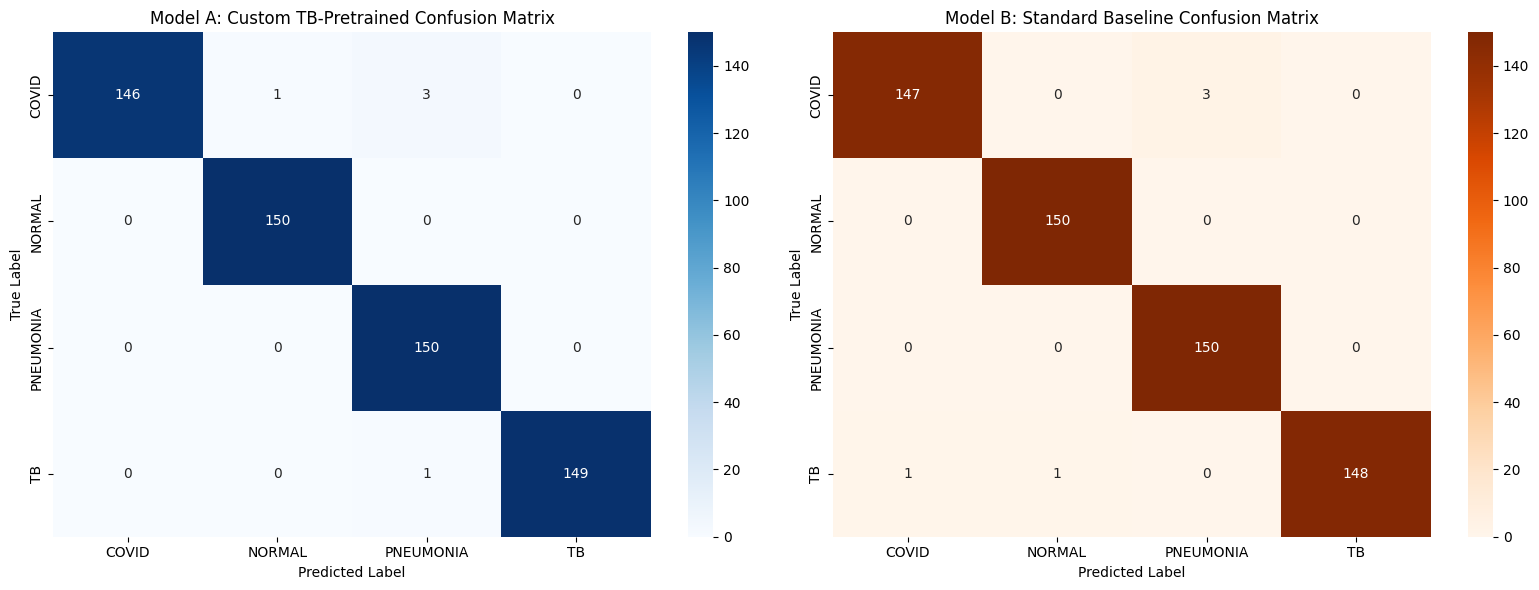


 CLASSIFICATION REPORT: MODEL A (PRETRAINED)
              precision    recall  f1-score   support

       COVID       1.00      0.97      0.99       150
      NORMAL       0.99      1.00      1.00       150
   PNEUMONIA       0.97      1.00      0.99       150
          TB       1.00      0.99      1.00       150

    accuracy                           0.99       600
   macro avg       0.99      0.99      0.99       600
weighted avg       0.99      0.99      0.99       600


 CLASSIFICATION REPORT: MODEL B (BASELINE)
              precision    recall  f1-score   support

       COVID       0.99      0.98      0.99       150
      NORMAL       0.99      1.00      1.00       150
   PNEUMONIA       0.98      1.00      0.99       150
          TB       1.00      0.99      0.99       150

    accuracy                           0.99       600
   macro avg       0.99      0.99      0.99       600
weighted avg       0.99      0.99      0.99       600



In [6]:
# --- 1. Configurations & Environment Setup ---
CXR_KANO_DIR = "/kaggle/input/datasets/spark2026nc/cxr-kano/cxr-kano"
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
CLASS_NAMES = ['COVID', 'NORMAL', 'PNEUMONIA', 'TB']

test_transforms = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

test_dataset = ImageFolder(root=os.path.join(CXR_KANO_DIR, "test_folder"), transform=test_transforms)
test_loader = DataLoader(test_dataset, batch_size=32, shuffle=False, num_workers=4)

# --- 2. Prediction Extraction Engine ---
def get_predictions(model_path):
    model = densenet121(weights=None)
    model.classifier = torch.nn.Linear(model.classifier.in_features, 4)
    model.load_state_dict(torch.load(model_path, map_location=DEVICE))
    model = model.to(DEVICE)
    model.eval()
    
    all_preds = []
    all_labels = []
    
    with torch.no_grad():
        for images, labels in test_loader:
            images = images.to(DEVICE)
            outputs = model(images)
            _, preds = outputs.max(1)
            
            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.numpy())
            
    return np.array(all_labels), np.array(all_preds)

# --- 3. Evaluate Both Models ---
print("Extracting predictions for Pretrained Model...")
labels_pre, preds_pre = get_predictions("kano_pretrained_best.pth")

print("Extracting predictions for Baseline Model...")
labels_base, preds_base = get_predictions("kano_baseline_best.pth")

# --- 4. Plot Side-by-Side Confusion Matrices ---
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Pretrained Matrix
cm_pre = confusion_matrix(labels_pre, preds_pre)
sns.heatmap(cm_pre, annot=True, fmt='d', cmap='Blues', ax=axes[0],
            xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES)
axes[0].set_title("Model A: Custom TB-Pretrained Confusion Matrix")
axes[0].set_xlabel("Predicted Label")
axes[0].set_ylabel("True Label")

# Baseline Matrix
cm_base = confusion_matrix(labels_base, preds_base)
sns.heatmap(cm_base, annot=True, fmt='d', cmap='Oranges', ax=axes[1],
            xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES)
axes[1].set_title("Model B: Standard Baseline Confusion Matrix")
axes[1].set_xlabel("Predicted Label")
axes[1].set_ylabel("True Label")

plt.tight_layout()
plt.savefig("mimic_confusion_comparison.png", dpi=300)
plt.show()

# --- 5. Print Detailed Performance Statistics ---
print("\n" + "="*60)
print(" CLASSIFICATION REPORT: MODEL A (PRETRAINED)")
print("="*60)
print(classification_report(labels_pre, preds_pre, target_names=CLASS_NAMES))

print("\n" + "="*60)
print(" CLASSIFICATION REPORT: MODEL B (BASELINE)")
print("="*60)
print(classification_report(labels_base, preds_base, target_names=CLASS_NAMES))

# Phase 4: Model Explainability Using Grad-CAM
        To satisfy our final project objective—ensuring that the model is making decisions based on actual lung opacities and infiltrative patterns rather than edge artifacts, textual annotations, or scanner noise—we will implement Grad-CAM.  Grad-CAM calculates the gradients of the score for a specific class with respect to the feature map activations of the very last convolutional layer of DenseNet121 (model.features.norm5). This highlights exactly where the network is "looking" when making a prediction.

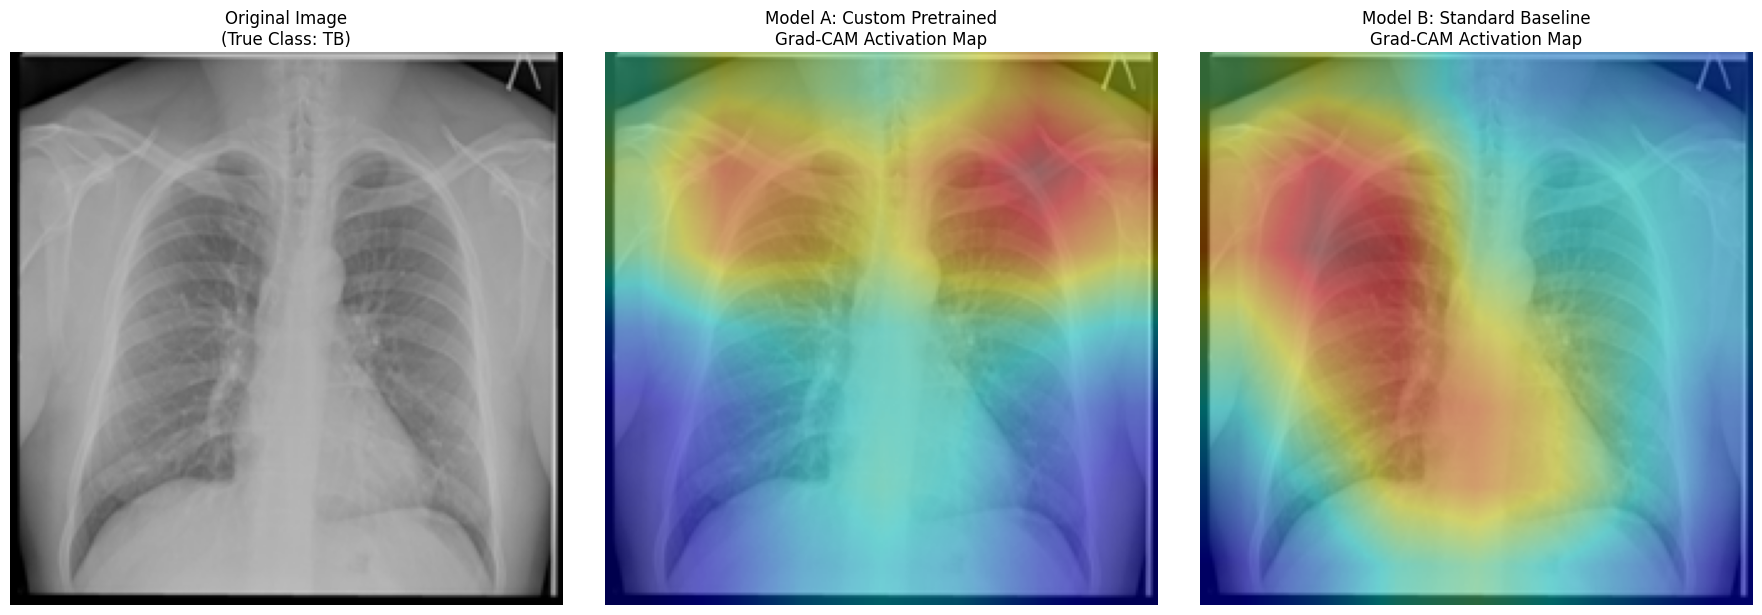

In [8]:
# --- 1. Grad-CAM Class Definition ---
class GradCAM:
    def __init__(self, model, target_layer):
        self.model = model
        self.target_layer = target_layer
        self.gradients = None
        self.activations = None
        
        # 1. Forward hook stays the same to capture activations
        self.forward_hook = target_layer.register_forward_hook(self.save_activation)
        # 2. We will handle backward gradients dynamically inside the forward hook instead
        self.backward_hook = None
        
    def save_activation(self, module, input, output):
        self.activations = output.detach()
        
        # 💡 SOLUTION: Register a tensor hook directly on the output tensor 
        # during the forward execution. This avoids container view-modification restrictions.
        def save_gradient_tensor(grad):
            # Using .clone() creates an isolated copy of the gradient tensor memory space
            self.gradients = grad.detach().clone()
            
        # Every time this tensor calculates gradients, it cleanly copies them to self.gradients
        output.register_hook(save_gradient_tensor)
        
    def generate_heatmap(self, input_tensor, class_idx):
        self.model.zero_grad()
        output = self.model(input_tensor)
        
        if class_idx is None:
            class_idx = torch.argmax(output, dim=1).item()
            
        loss = output[0, class_idx]
        loss.backward()
        
        # Safety check to make sure gradients were collected
        if self.gradients is None:
            raise RuntimeError("❌ Gradients were not captured! Double check your target layer path.")
        
        # Pool the gradients across channels
        pooled_gradients = torch.mean(self.gradients, dim=[0, 2, 3])
        
        # Clone activations to avoid changing them in-place during the weighting step
        activations_copy = self.activations.clone()
        
        # Weight the channels by the pooled gradients
        for i in range(activations_copy.shape[1]):
            activations_copy[0, i, :, :] *= pooled_gradients[i]
            
        # Compute the heatmap via a ReLU activation
        heatmap = torch.mean(activations_copy, dim=1).squeeze().cpu().numpy()
        heatmap = np.maximum(heatmap, 0) # ReLU operation
        
        # Normalize between 0 and 1
        if np.max(heatmap) != 0:
            heatmap /= np.max(heatmap)
            
        return heatmap

    def remove_hooks(self):
        self.forward_hook.remove()
        if self.backward_hook is not None:
            self.backward_hook.remove()

# --- 2. Target Generation Execution Pipeline ---
def apply_gradcam_comparison(image_path, true_class_name, target_class_idx=3):
    """
    Loads an image, runs it through both models, generates heatmaps for the 
    specified target class (default: 3 for TB), and plots them side-by-side.
    """
    DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    
    # Transformation pipeline (without random augmentations)
    eval_transforms = transforms.Compose([
        transforms.Resize((224, 224)),
        transforms.ToTensor(),
        transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
    ])
    
    # Preprocess image
    raw_img = Image.open(image_path).convert("RGB")
    input_tensor = eval_transforms(raw_img).unsqueeze(0).to(DEVICE)
    
    # Setup Models and load final weights
    def load_model(weights_path):
        m = densenet121(weights=None)
        m.classifier = torch.nn.Linear(m.classifier.in_features, 4)
        m.load_state_dict(torch.load(weights_path, map_location=DEVICE))
        return m.to(DEVICE).eval()
    
    model_pre = load_model("kano_pretrained_best.pth")
    model_base = load_model("kano_baseline_best.pth")
    
    # Choose DenseNet121 final normalization layer as target
    target_layer_pre = model_pre.features.norm5
    target_layer_base = model_base.features.norm5
    
    # Extract Heatmaps
    cam_pre = GradCAM(model_pre, target_layer_pre)
    heatmap_pre = cam_pre.generate_heatmap(input_tensor, class_idx=target_class_idx)
    cam_pre.remove_hooks()
    
    cam_base = GradCAM(model_base, target_layer_base)
    heatmap_base = cam_base.generate_heatmap(input_tensor, class_idx=target_class_idx)
    cam_base.remove_hooks()
    
    # Post-process Heatmaps for overlaying
    img_cv = cv2.resize(cv2.imread(image_path), (224, 224))
    
    def overlay_heatmap(heatmap, img):
        h_resized = cv2.resize(heatmap, (img.shape[1], img.shape[0]))
        h_colored = cv2.applyColorMap(np.uint8(255 * h_resized), cv2.COLORMAP_JET)
        overlayed = cv2.addWeighted(img, 0.6, h_colored, 0.4, 0)
        return cv2.cvtColor(overlayed, cv2.COLOR_BGR2RGB)
    
    visual_pre = overlay_heatmap(heatmap_pre, img_cv)
    visual_base = overlay_heatmap(heatmap_base, img_cv)
    
    # Plot Results side-by-side
    fig, axes = plt.subplots(1, 3, figsize=(18, 6))
    axes[0].imshow(cv2.cvtColor(img_cv, cv2.COLOR_BGR2RGB))
    axes[0].set_title(f"Original Image\n(True Class: {true_class_name})")
    axes[0].axis('off')
    
    axes[1].imshow(visual_pre)
    axes[1].set_title("Model A: Custom Pretrained\nGrad-CAM Activation Map")
    axes[1].axis('off')
    
    axes[2].imshow(visual_base)
    axes[2].set_title("Model B: Standard Baseline\nGrad-CAM Activation Map")
    axes[2].axis('off')
    
    plt.tight_layout()
    plt.savefig("gradcam_comparison_output.png", dpi=300)
    plt.show()

# --- 3. Example Execution Call ---
if __name__ == "__main__":
    # Test on a single sample from your TB test directory
    # Adjust this path to match an actual image in your local workspace
    sample_tb_image = "/kaggle/input/datasets/spark2026nc/cxr-kano/cxr-kano/test_folder/TB/Tuberculosis-501.png"
    
    if os.path.exists(sample_tb_image):
        apply_gradcam_comparison(sample_tb_image, true_class_name="TB", target_class_idx=3)
    else:
        print(f"⚠️ Please update 'sample_tb_image' with a valid local path to verify the visualization.")

## New Experiment 

## Model A

## Phase 1

In [ ]:
import os
import glob
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader, SubsetRandomSampler
import torchvision.transforms as transforms
from torchvision.models import densenet121, DenseNet121_Weights
from sklearn.model_selection import KFold
import matplotlib.pyplot as plt
from tqdm import tqdm

from PIL import Image
import matplotlib.pyplot as plt
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns

Starting 5-Fold Cross Validation Pretraining on cuda...
Total dataset size: 4200 images

🌀 EXECUTING FOLD 1 / 5
Downloading: "https://download.pytorch.org/models/densenet121-a639ec97.pth" to /root/.cache/torch/hub/checkpoints/densenet121-a639ec97.pth


100%|██████████| 30.8M/30.8M [00:00<00:00, 200MB/s]


Epoch [00/20]: Initial Baseline Loss: 1.3338 (Train) | 0.7828 (Val)
Epoch [01/20]: Train Loss: 0.1529 | Val Loss: 0.0320
Epoch [02/20]: Train Loss: 0.0333 | Val Loss: 0.0191
Epoch [03/20]: Train Loss: 0.0184 | Val Loss: 0.0170
Epoch [04/20]: Train Loss: 0.0121 | Val Loss: 0.0100
Epoch [05/20]: Train Loss: 0.0087 | Val Loss: 0.0037
Epoch [06/20]: Train Loss: 0.0069 | Val Loss: 0.0022
Epoch [07/20]: Train Loss: 0.0025 | Val Loss: 0.0071
Epoch [08/20]: Train Loss: 0.0053 | Val Loss: 0.0034
Epoch [09/20]: Train Loss: 0.0020 | Val Loss: 0.0010
Epoch [10/20]: Train Loss: 0.0010 | Val Loss: 0.0012
Epoch [11/20]: Train Loss: 0.0008 | Val Loss: 0.0010
Epoch [12/20]: Train Loss: 0.0006 | Val Loss: 0.0011
Epoch [13/20]: Train Loss: 0.0007 | Val Loss: 0.0013
Epoch [14/20]: Train Loss: 0.0030 | Val Loss: 0.0012
Epoch [15/20]: Train Loss: 0.0012 | Val Loss: 0.0008
Epoch [16/20]: Train Loss: 0.0011 | Val Loss: 0.0007
Epoch [17/20]: Train Loss: 0.0006 | Val Loss: 0.0006
Epoch [18/20]: Train Loss: 0.00

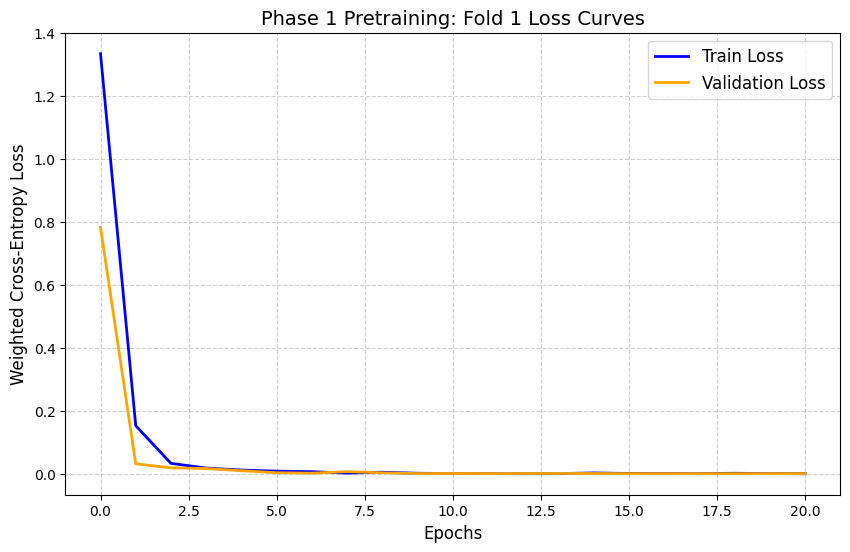

📉 Saved Loss Graph for Fold 1 as 'phase1_fold_1_loss.png'


🌀 EXECUTING FOLD 2 / 5
Epoch [00/20]: Initial Baseline Loss: 0.6715 (Train) | 0.6791 (Val)
Epoch [01/20]: Train Loss: 0.1279 | Val Loss: 0.0447
Epoch [02/20]: Train Loss: 0.0343 | Val Loss: 0.0242
Epoch [03/20]: Train Loss: 0.0151 | Val Loss: 0.0230
Epoch [04/20]: Train Loss: 0.0124 | Val Loss: 0.0222
Epoch [05/20]: Train Loss: 0.0089 | Val Loss: 0.0130
Epoch [06/20]: Train Loss: 0.0082 | Val Loss: 0.0146
Epoch [07/20]: Train Loss: 0.0054 | Val Loss: 0.0089
Epoch [08/20]: Train Loss: 0.0117 | Val Loss: 0.0142
Epoch [09/20]: Train Loss: 0.0017 | Val Loss: 0.0184
Epoch [10/20]: Train Loss: 0.0024 | Val Loss: 0.0183
Epoch [11/20]: Train Loss: 0.0052 | Val Loss: 0.0123
Epoch [12/20]: Train Loss: 0.0015 | Val Loss: 0.0153
Epoch [13/20]: Train Loss: 0.0027 | Val Loss: 0.0296
Epoch [14/20]: Train Loss: 0.0018 | Val Loss: 0.0230
Epoch [15/20]: Train Loss: 0.0009 | Val Loss: 0.0164
Epoch [16/20]: Train Loss: 0.0006 | Val Loss: 0.0185
E

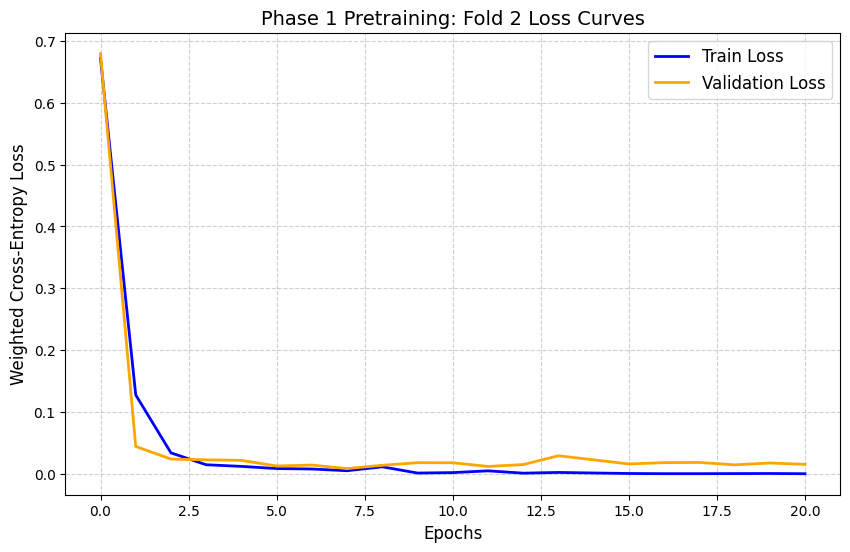

📉 Saved Loss Graph for Fold 2 as 'phase1_fold_2_loss.png'


🌀 EXECUTING FOLD 3 / 5
Epoch [00/20]: Initial Baseline Loss: 0.8916 (Train) | 0.8017 (Val)
Epoch [01/20]: Train Loss: 0.1400 | Val Loss: 0.0725
Epoch [02/20]: Train Loss: 0.0347 | Val Loss: 0.0279
Epoch [03/20]: Train Loss: 0.0088 | Val Loss: 0.0372
Epoch [04/20]: Train Loss: 0.0163 | Val Loss: 0.0399
Epoch [05/20]: Train Loss: 0.0088 | Val Loss: 0.0408
Epoch [06/20]: Train Loss: 0.0122 | Val Loss: 0.0527
Epoch [07/20]: Train Loss: 0.0032 | Val Loss: 0.0160
Epoch [08/20]: Train Loss: 0.0082 | Val Loss: 0.0156
Epoch [09/20]: Train Loss: 0.0038 | Val Loss: 0.0286
Epoch [10/20]: Train Loss: 0.0012 | Val Loss: 0.0172
Epoch [11/20]: Train Loss: 0.0009 | Val Loss: 0.0243
Epoch [12/20]: Train Loss: 0.0018 | Val Loss: 0.0162
Epoch [13/20]: Train Loss: 0.0015 | Val Loss: 0.0101
Epoch [14/20]: Train Loss: 0.0009 | Val Loss: 0.0082
Epoch [15/20]: Train Loss: 0.0021 | Val Loss: 0.0134
Epoch [16/20]: Train Loss: 0.0023 | Val Loss: 0.0179
E

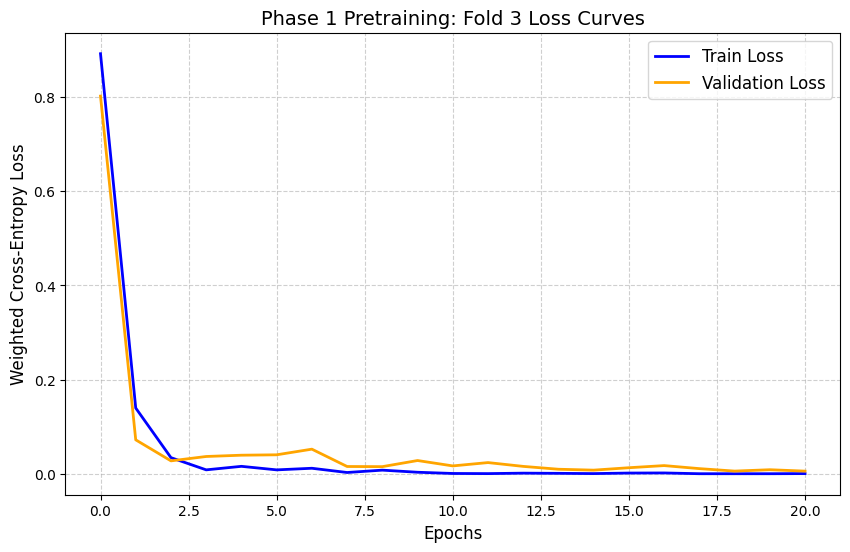

📉 Saved Loss Graph for Fold 3 as 'phase1_fold_3_loss.png'


🌀 EXECUTING FOLD 4 / 5
Epoch [00/20]: Initial Baseline Loss: 0.6390 (Train) | 0.6258 (Val)
Epoch [01/20]: Train Loss: 0.1245 | Val Loss: 0.0496
Epoch [02/20]: Train Loss: 0.0276 | Val Loss: 0.0184
Epoch [03/20]: Train Loss: 0.0169 | Val Loss: 0.0251
Epoch [04/20]: Train Loss: 0.0106 | Val Loss: 0.0035
Epoch [05/20]: Train Loss: 0.0141 | Val Loss: 0.0195
Epoch [06/20]: Train Loss: 0.0091 | Val Loss: 0.0014
Epoch [07/20]: Train Loss: 0.0031 | Val Loss: 0.0033
Epoch [08/20]: Train Loss: 0.0013 | Val Loss: 0.0015
Epoch [09/20]: Train Loss: 0.0058 | Val Loss: 0.0024
Epoch [10/20]: Train Loss: 0.0022 | Val Loss: 0.0008
Epoch [11/20]: Train Loss: 0.0011 | Val Loss: 0.0009
Epoch [12/20]: Train Loss: 0.0008 | Val Loss: 0.0006
Epoch [13/20]: Train Loss: 0.0008 | Val Loss: 0.0003
Epoch [14/20]: Train Loss: 0.0005 | Val Loss: 0.0005
Epoch [15/20]: Train Loss: 0.0010 | Val Loss: 0.0003
Epoch [16/20]: Train Loss: 0.0005 | Val Loss: 0.0003
E

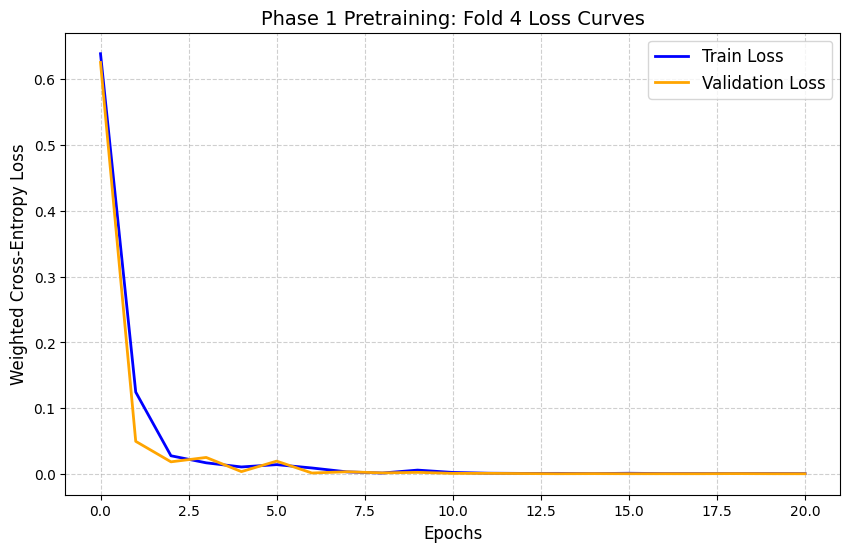

📉 Saved Loss Graph for Fold 4 as 'phase1_fold_4_loss.png'


🌀 EXECUTING FOLD 5 / 5
Epoch [00/20]: Initial Baseline Loss: 0.5131 (Train) | 0.8007 (Val)
Epoch [01/20]: Train Loss: 0.1333 | Val Loss: 0.0180
Epoch [02/20]: Train Loss: 0.0336 | Val Loss: 0.0142
Epoch [03/20]: Train Loss: 0.0174 | Val Loss: 0.0036
Epoch [04/20]: Train Loss: 0.0165 | Val Loss: 0.0054
Epoch [05/20]: Train Loss: 0.0061 | Val Loss: 0.0004
Epoch [06/20]: Train Loss: 0.0043 | Val Loss: 0.0013
Epoch [07/20]: Train Loss: 0.0074 | Val Loss: 0.0011
Epoch [08/20]: Train Loss: 0.0022 | Val Loss: 0.0002
Epoch [09/20]: Train Loss: 0.0013 | Val Loss: 0.0002
Epoch [10/20]: Train Loss: 0.0011 | Val Loss: 0.0002
Epoch [11/20]: Train Loss: 0.0017 | Val Loss: 0.0003
Epoch [12/20]: Train Loss: 0.0023 | Val Loss: 0.0003
Epoch [13/20]: Train Loss: 0.0009 | Val Loss: 0.0002
Epoch [14/20]: Train Loss: 0.0040 | Val Loss: 0.0008
Epoch [15/20]: Train Loss: 0.0054 | Val Loss: 0.0007
Epoch [16/20]: Train Loss: 0.0013 | Val Loss: 0.0005
E

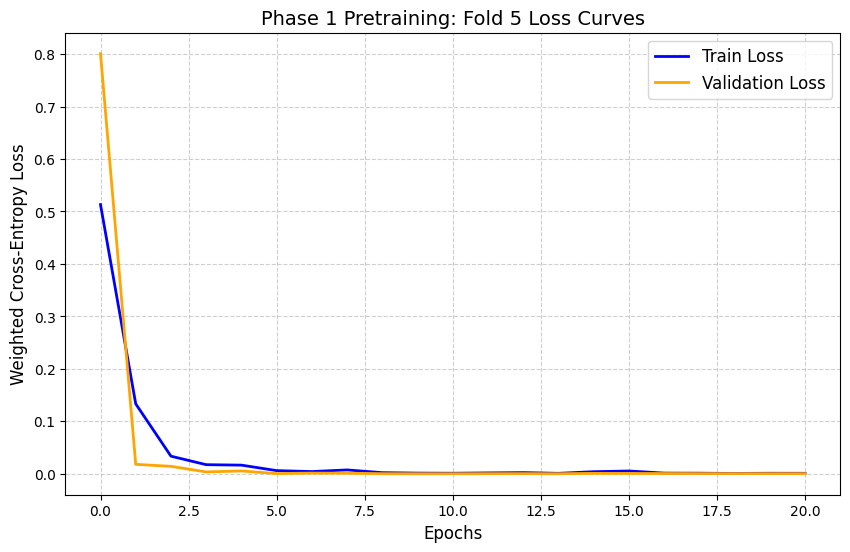

📉 Saved Loss Graph for Fold 5 as 'phase1_fold_5_loss.png'



In [1]:
# --- 1. Base Configurations ---
NIAID_CXR_DIR = "/kaggle/input/datasets/spark2026nc/niaid-cxr/niaid-cxr"
BATCH_SIZE = 32
EPOCHS = 20
NUM_FOLDS = 5
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
SEED = 42

# Ensure reproducibility across folds
torch.manual_seed(SEED)
np.random.seed(SEED)

# --- 2. Comprehensive Dataset Parser ---
class NiaidFullDataset(Dataset):
    """Loads all images from the flat raw folders without splitting internally."""
    def __init__(self, base_dir, transform=None):
        self.base_dir = base_dir
        self.transform = transform
        self.image_data = []
        
        for label_idx, class_name in enumerate(["Normal", "Tuberculosis"]):
            class_folder = os.path.join(base_dir, class_name)
            images = sorted(glob.glob(os.path.join(class_folder, "*.png")))
            for img_path in images:
                self.image_data.append((img_path, label_idx))
                
    def __len__(self):
        return len(self.image_data)

    def __getitem__(self, idx):
        img_path, label = self.image_data[idx]
        from PIL import Image
        image = Image.open(img_path).convert("RGB")
        if self.transform:
            image = self.transform(image)
        return image, torch.tensor(label, dtype=torch.long)

# --- 3. Augmentation & Normalization Pipelines ---
train_transforms = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomRotation(degrees=15),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

val_transforms = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

# --- 4. Plotting Function for Loss Curves ---
def plot_fold_loss(train_losses, val_losses, fold_idx):
    plt.figure(figsize=(10, 6))
    # Corrected x-axis coordinates to encompass the baseline at index 0
    epochs_range = range(0, len(train_losses))
    
    plt.plot(epochs_range, train_losses, label='Train Loss', color='blue', lw=2)
    plt.plot(epochs_range, val_losses, label='Validation Loss', color='orange', lw=2)
    plt.title(f'Phase 1 Pretraining: Fold {fold_idx} Loss Curves', fontsize=14)
    plt.xlabel('Epochs', fontsize=12)
    plt.ylabel('Weighted Cross-Entropy Loss', fontsize=12)
    plt.grid(True, linestyle='--', alpha=0.6)
    plt.legend(fontsize=12)
    
    # Save the chart locally
    graph_filename = f"phase1_fold_{fold_idx}_loss.png"
    plt.savefig(graph_filename, dpi=300, bbox_inches='tight')
    plt.show()
    print(f"📉 Saved Loss Graph for Fold {fold_idx} as '{graph_filename}'\n")

# --- 5. 5-Fold Cross-Validation Core Engine ---
def run_cross_validated_pretraining():
    # Instantiate two versions of the dataset to separate train/val transforms
    full_dataset_train = NiaidFullDataset(NIAID_CXR_DIR, transform=train_transforms)
    full_dataset_val = NiaidFullDataset(NIAID_CXR_DIR, transform=val_transforms)
    
    # Initialize KFold split configuration
    kfold = KFold(n_splits=NUM_FOLDS, shuffle=True, random_state=SEED)
    
    print(f"Starting 5-Fold Cross Validation Pretraining on {DEVICE}...")
    print(f"Total dataset size: {len(full_dataset_train)} images")
    
    # Calculate dataset-wide class balancing weights (3500 Normal, 700 TB)
    loss_weights = torch.tensor([0.6, 3.0], dtype=torch.float).to(DEVICE)
    
    for fold, (train_ids, val_ids) in enumerate(kfold.split(full_dataset_train)):
        print("\n" + "="*60)
        print(f"🌀 EXECUTING FOLD {fold + 1} / {NUM_FOLDS}")
        print("="*60)
        
        # Samplers pick correct indices for the current fold configuration
        train_sampler = SubsetRandomSampler(train_ids)
        val_sampler = SubsetRandomSampler(val_ids)
        
        train_loader = DataLoader(full_dataset_train, batch_size=BATCH_SIZE, sampler=train_sampler, num_workers=4, pin_memory=True)
        val_loader = DataLoader(full_dataset_val, batch_size=BATCH_SIZE, sampler=val_sampler, num_workers=4, pin_memory=True)
        
        # Fresh initialization of DenseNet121 for each fold to ensure independent learning
        model = densenet121(weights=DenseNet121_Weights.DEFAULT)
        model.classifier = nn.Linear(model.classifier.in_features, 2)
        model = model.to(DEVICE)
        
        criterion = nn.CrossEntropyLoss(weight=loss_weights)
        optimizer = optim.AdamW(model.parameters(), lr=1e-4, weight_decay=1e-2)
        scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=EPOCHS)
        
        fold_train_losses = []
        fold_val_losses = []
        best_fold_loss = float('inf')
        
        # --- Compute True Initialization Baseline (Epoch 0) ---
        model.eval()
        with torch.no_grad():
            init_train_iter = iter(train_loader)
            init_images_t, init_labels_t = next(init_train_iter)
            init_images_t, init_labels_t = init_images_t.to(DEVICE), init_labels_t.to(DEVICE)
            init_train_loss = criterion(model(init_images_t), init_labels_t).item()
            
            init_val_iter = iter(val_loader)
            init_images_v, init_labels_v = next(init_val_iter)
            init_images_v, init_labels_v = init_images_v.to(DEVICE), init_labels_v.to(DEVICE)
            init_val_loss = criterion(model(init_images_v), init_labels_v).item()
            
        fold_train_losses.append(init_train_loss)
        fold_val_losses.append(init_val_loss)
        print(f"Epoch [00/{EPOCHS}]: Initial Baseline Loss: {init_train_loss:.4f} (Train) | {init_val_loss:.4f} (Val)")
        
        for epoch in range(EPOCHS):
            # --- Training Mode ---
            model.train()
            running_train_loss = 0.0
            train_total = 0
            
            for images, labels in train_loader:
                images, labels = images.to(DEVICE), labels.to(DEVICE)
                
                optimizer.zero_grad()
                outputs = model(images)
                loss = criterion(outputs, labels)
                loss.backward()
                optimizer.step()
                
                running_train_loss += loss.item() * images.size(0)
                train_total += labels.size(0)
                
            scheduler.step()
            epoch_train_loss = running_train_loss / train_total
            fold_train_losses.append(epoch_train_loss)
            
            # --- Validation Mode ---
            model.eval()
            running_val_loss = 0.0
            val_total = 0
            
            with torch.no_grad():
                for images, labels in val_loader:
                    images, labels = images.to(DEVICE), labels.to(DEVICE)
                    outputs = model(images)
                    loss = criterion(outputs, labels)
                    
                    running_val_loss += loss.item() * images.size(0)
                    val_total += labels.size(0)
                    
            epoch_val_loss = running_val_loss / val_total
            fold_val_losses.append(epoch_val_loss)
            
            print(f"Epoch [{epoch+1:02d}/{EPOCHS}]: Train Loss: {epoch_train_loss:.4f} | Val Loss: {epoch_val_loss:.4f}")
            
            # Checkpoint the optimal weights within this specific fold loop
            if epoch_val_loss < best_fold_loss:
                best_fold_loss = epoch_val_loss
                torch.save(model.state_dict(), f"tb_pretrained_backbone_fold{fold+1}.pth")
        
        # --- End of Fold Execution ---
        print(f"\nFold {fold + 1} processing complete. Rendering validation plot...")
        plot_fold_loss(fold_train_losses, fold_val_losses, fold_idx=fold + 1)

if __name__ == "__main__":
    run_cross_validated_pretraining()

## Phase 2 : 4-Class Fine-Tuning with 5-Fold CV

 Launching Optimized Fine-Tuning Run on cuda...

🌀 EXECUTING OPTIMIZED FOLD 1 / 5


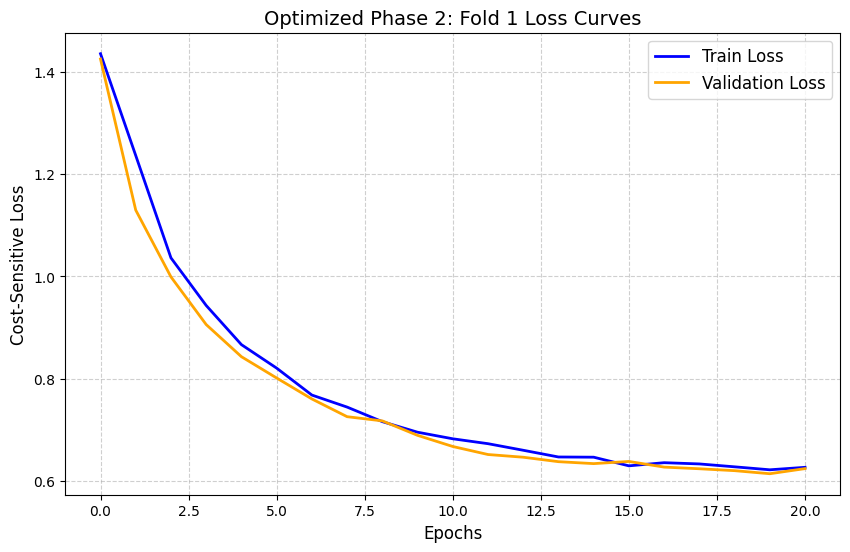


🌀 EXECUTING OPTIMIZED FOLD 2 / 5


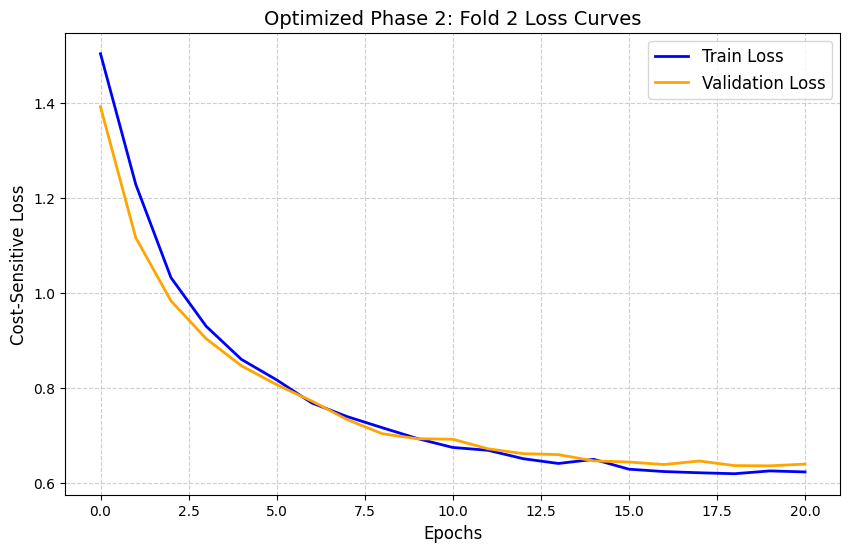


🌀 EXECUTING OPTIMIZED FOLD 3 / 5


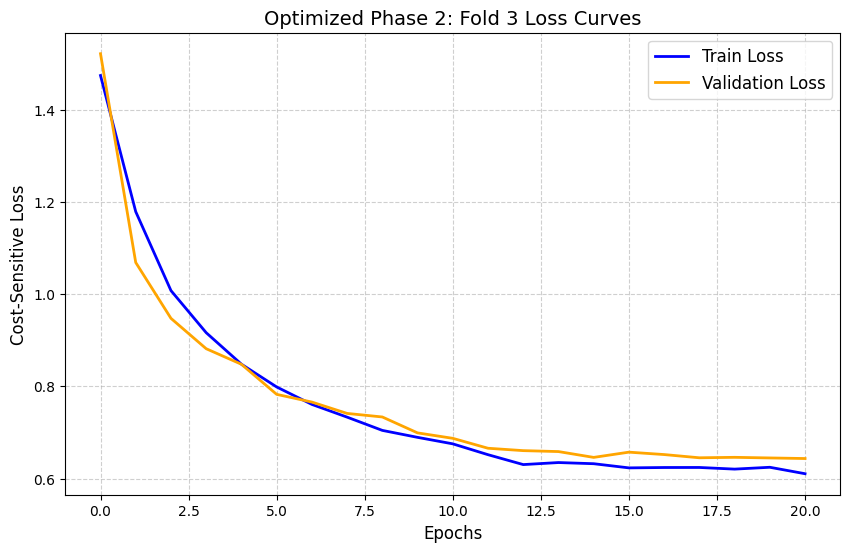


🌀 EXECUTING OPTIMIZED FOLD 4 / 5


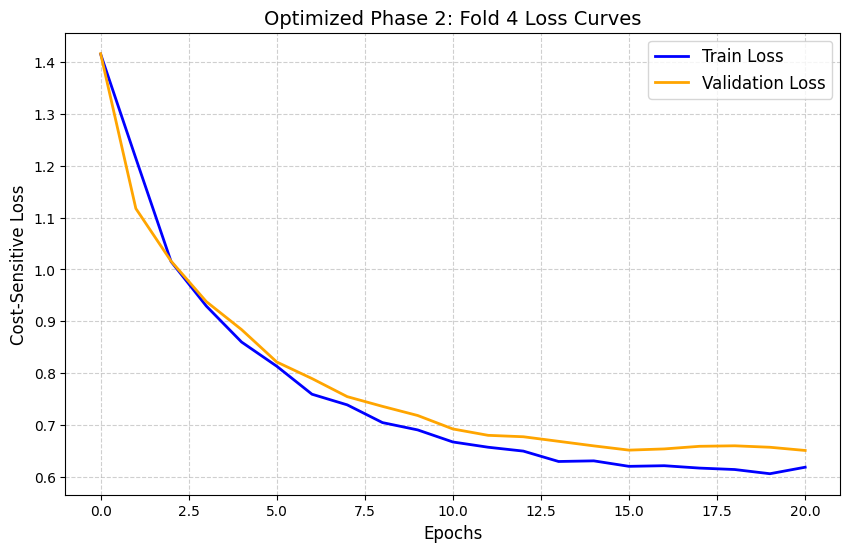


🌀 EXECUTING OPTIMIZED FOLD 5 / 5


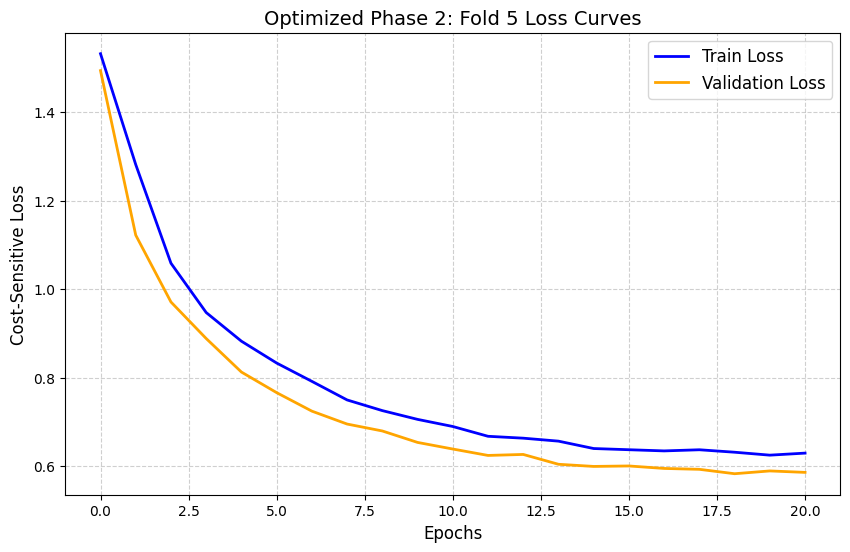

In [3]:
import os
import glob
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader, SubsetRandomSampler
import torchvision.transforms as transforms
from torchvision.models import densenet121
from sklearn.model_selection import KFold
import matplotlib.pyplot as plt
from tqdm import tqdm

# --- 1. Base Configurations ---
KANO_CXR_DIR = "/kaggle/input/datasets/spark2026nc/cxr-kano/cxr-kano/train_folder" 
BATCH_SIZE = 32
EPOCHS = 20
NUM_FOLDS = 5
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
SEED = 42

torch.manual_seed(SEED)
np.random.seed(SEED)

# --- 2. Dataset Parser ---
class KanoFullDataset(Dataset):
    def __init__(self, base_dir, transform=None):
        self.base_dir = base_dir
        self.transform = transform
        self.image_data = []
        self.class_names = ["COVID", "NORMAL", "PNEUMONIA", "TB"]
        
        for label_idx, class_name in enumerate(self.class_names):
            class_folder = os.path.join(base_dir, class_name)
            images = sorted(glob.glob(os.path.join(class_folder, "*.png")) + 
                            glob.glob(os.path.join(class_folder, "*.jpg")) + 
                            glob.glob(os.path.join(class_folder, "*.jpeg")))
            for img_path in images:
                self.image_data.append((img_path, label_idx))
                
    def __len__(self):
        return len(self.image_data)

    def __getitem__(self, idx):
        img_path, label = self.image_data[idx]
        from PIL import Image
        image = Image.open(img_path).convert("RGB")
        if self.transform:
            image = self.transform(image)
        return image, torch.tensor(label, dtype=torch.long)

# --- 3. Transformations ---
train_transforms = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomRotation(degrees=15),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

val_transforms = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

def plot_optimized_loss(train_losses, val_losses, fold_idx):
    plt.figure(figsize=(10, 6))
    epochs_range = range(0, len(train_losses))
    plt.plot(epochs_range, train_losses, label='Train Loss', color='blue', lw=2)
    plt.plot(epochs_range, val_losses, label='Validation Loss', color='orange', lw=2)
    plt.title(f'Optimized Phase 2: Fold {fold_idx} Loss Curves', fontsize=14)
    plt.xlabel('Epochs', fontsize=12)
    plt.ylabel('Cost-Sensitive Loss', fontsize=12)
    plt.grid(True, linestyle='--', alpha=0.6)
    plt.legend(fontsize=12)
    plt.savefig(f"optimized_phase2_fold_{fold_idx}_loss.png", dpi=300, bbox_inches='tight')
    plt.show()

# --- 4. Main Optimization Run ---
def run_optimized_finetuning():
    full_dataset_train = KanoFullDataset(KANO_CXR_DIR, transform=train_transforms)
    full_dataset_val = KanoFullDataset(KANO_CXR_DIR, transform=val_transforms)
    kfold = KFold(n_splits=NUM_FOLDS, shuffle=True, random_state=SEED)
    
    print(f" Launching Optimized Fine-Tuning Run on {DEVICE}...")
    
    # CRITICAL: Injecting Cost-Sensitive Weights + Label Smoothing
    # Ordering: [COVID (1.5), NORMAL (1.0), PNEUMONIA (1.0), TB (2.2)]
    loss_weights = torch.tensor([1.5, 1.0, 1.0, 2.2], dtype=torch.float).to(DEVICE)
    criterion = nn.CrossEntropyLoss(weight=loss_weights, label_smoothing=0.1)
    
    for fold, (train_ids, val_ids) in enumerate(kfold.split(full_dataset_train)):
        print(f"\n🌀 EXECUTING OPTIMIZED FOLD {fold + 1} / {NUM_FOLDS}")
        
        train_sampler = SubsetRandomSampler(train_ids)
        val_sampler = SubsetRandomSampler(val_ids)
        
        train_loader = DataLoader(full_dataset_train, batch_size=BATCH_SIZE, sampler=train_sampler, num_workers=4, pin_memory=True)
        val_loader = DataLoader(full_dataset_val, batch_size=BATCH_SIZE, sampler=val_sampler, num_workers=4, pin_memory=True)
        
        # Build framework and load the checkpoint from Phase 1
        model = densenet121(weights=None)
        model.classifier = nn.Linear(model.classifier.in_features, 2)
        
        checkpoint_path = f"tb_pretrained_backbone_fold{fold+1}.pth"
        if os.path.exists(checkpoint_path):
            model.load_state_dict(torch.load(checkpoint_path, map_location=DEVICE))
            
        model.classifier = nn.Linear(model.classifier.in_features, 4)
        model = model.to(DEVICE)
        
        optimizer = optim.AdamW(model.parameters(), lr=1e-5, weight_decay=1e-2)
        scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=EPOCHS)
        
        fold_train_losses = []
        fold_val_losses = []
        best_fold_loss = float('inf')
        
        # --- Compute Epoch 0 Baseline ---
        model.eval()
        with torch.no_grad():
            init_images_t, init_labels_t = next(iter(train_loader))
            init_train_loss = criterion(model(init_images_t.to(DEVICE)), init_labels_t.to(DEVICE)).item()
            init_images_v, init_labels_v = next(iter(val_loader))
            init_val_loss = criterion(model(init_images_v.to(DEVICE)), init_labels_v.to(DEVICE)).item()
            
        fold_train_losses.append(init_train_loss)
        fold_val_losses.append(init_val_loss)
        
        for epoch in range(EPOCHS):
            model.train()
            running_train_loss = 0.0
            train_total = 0
            for images, labels in train_loader:
                images, labels = images.to(DEVICE), labels.to(DEVICE)
                optimizer.zero_grad()
                loss = criterion(model(images), labels)
                loss.backward()
                optimizer.step()
                running_train_loss += loss.item() * images.size(0)
                train_total += labels.size(0)
                
            scheduler.step()
            epoch_train_loss = running_train_loss / train_total
            fold_train_losses.append(epoch_train_loss)
            
            model.eval()
            running_val_loss = 0.0
            val_total = 0
            with torch.no_grad():
                for images, labels in val_loader:
                    images, labels = images.to(DEVICE), labels.to(DEVICE)
                    loss = criterion(model(images), labels)
                    running_val_loss += loss.item() * images.size(0)
                    val_total += labels.size(0)
                    
            epoch_val_loss = running_val_loss / val_total
            fold_val_losses.append(epoch_val_loss)
            
            if epoch_val_loss < best_fold_loss:
                best_fold_loss = epoch_val_loss
                # We save this with a distinct prefix so it doesn't overwrite your previous work!
                torch.save(model.state_dict(), f"kano_optimized_fold{fold+1}.pth")
                
        plot_optimized_loss(fold_train_losses, fold_val_losses, fold_idx=fold + 1)

if __name__ == "__main__":
    run_optimized_finetuning()

## Model B

🚀 Launching Symmetrically Optimized Baseline (Model B) Run on cuda...

🧱 EXECUTING OPTIMIZED BASELINE FOLD 1 / 5
Downloading: "https://download.pytorch.org/models/densenet121-a639ec97.pth" to /root/.cache/torch/hub/checkpoints/densenet121-a639ec97.pth


100%|██████████| 30.8M/30.8M [00:00<00:00, 144MB/s] 


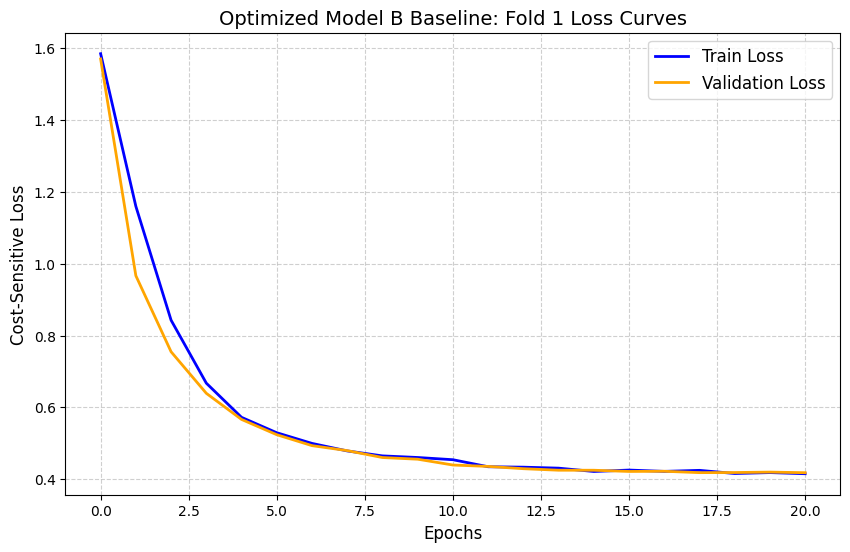


🧱 EXECUTING OPTIMIZED BASELINE FOLD 2 / 5


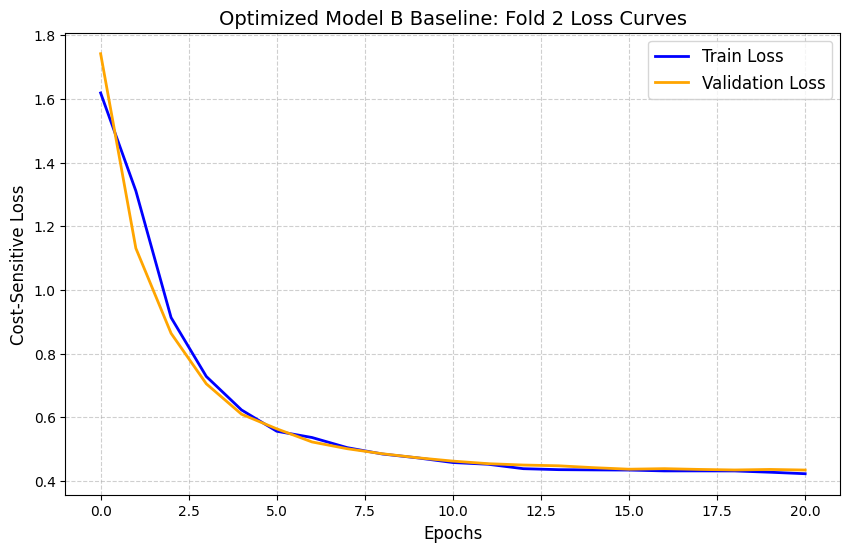


🧱 EXECUTING OPTIMIZED BASELINE FOLD 3 / 5


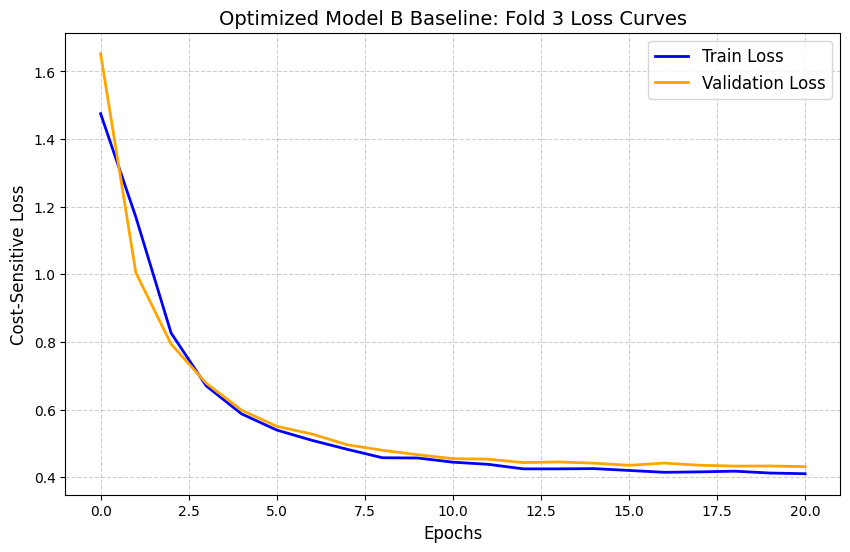


🧱 EXECUTING OPTIMIZED BASELINE FOLD 4 / 5


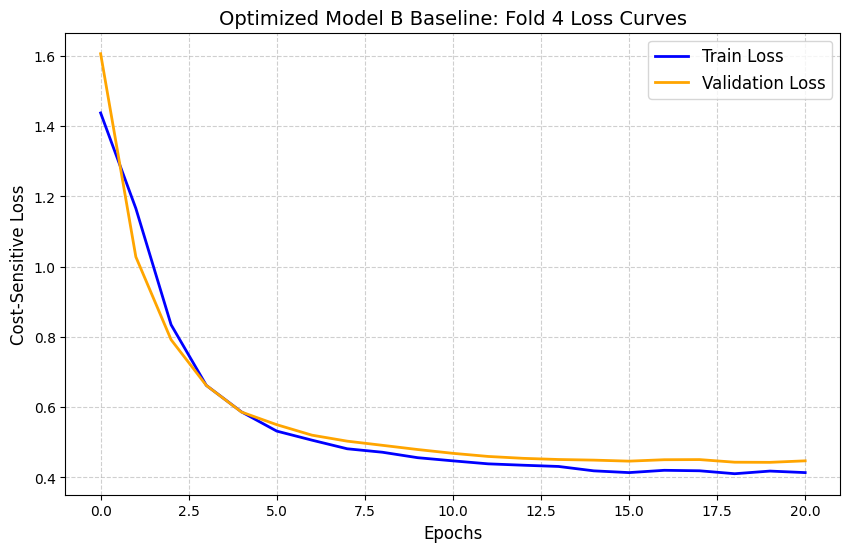


🧱 EXECUTING OPTIMIZED BASELINE FOLD 5 / 5


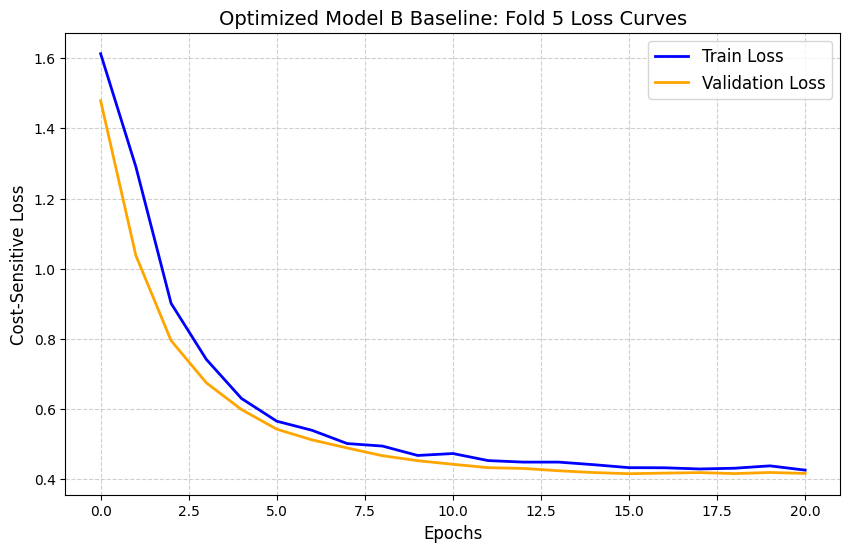

In [1]:
import os
import glob
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader, SubsetRandomSampler
import torchvision.transforms as transforms
from torchvision.models import densenet121, DenseNet121_Weights
from sklearn.model_selection import KFold
import matplotlib.pyplot as plt
from tqdm import tqdm

# --- 1. Base Configurations ---
KANO_CXR_DIR = "/kaggle/input/datasets/spark2026nc/cxr-kano/cxr-kano/train_folder" 
BATCH_SIZE = 32
EPOCHS = 20
NUM_FOLDS = 5
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
SEED = 42

torch.manual_seed(SEED)
np.random.seed(SEED)

# --- 2. Dataset Parser ---
class KanoFullDataset(Dataset):
    def __init__(self, base_dir, transform=None):
        self.base_dir = base_dir
        self.transform = transform
        self.image_data = []
        self.class_names = ["COVID", "NORMAL", "PNEUMONIA", "TB"]
        
        for label_idx, class_name in enumerate(self.class_names):
            class_folder = os.path.join(base_dir, class_name)
            images = sorted(glob.glob(os.path.join(class_folder, "*.png")) + 
                            glob.glob(os.path.join(class_folder, "*.jpg")) + 
                            glob.glob(os.path.join(class_folder, "*.jpeg")))
            for img_path in images:
                self.image_data.append((img_path, label_idx))
                
    def __len__(self):
        return len(self.image_data)

    def __getitem__(self, idx):
        img_path, label = self.image_data[idx]
        from PIL import Image
        image = Image.open(img_path).convert("RGB")
        if self.transform:
            image = self.transform(image)
        return image, torch.tensor(label, dtype=torch.long)

# --- 3. Transformations ---
train_transforms = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomRotation(degrees=15),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

val_transforms = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

def plot_optimized_baseline_loss(train_losses, val_losses, fold_idx):
    plt.figure(figsize=(10, 6))
    epochs_range = range(0, len(train_losses))
    plt.plot(epochs_range, train_losses, label='Train Loss', color='blue', lw=2)
    plt.plot(epochs_range, val_losses, label='Validation Loss', color='orange', lw=2)
    plt.title(f'Optimized Model B Baseline: Fold {fold_idx} Loss Curves', fontsize=14)
    plt.xlabel('Epochs', fontsize=12)
    plt.ylabel('Cost-Sensitive Loss', fontsize=12)
    plt.grid(True, linestyle='--', alpha=0.6)
    plt.legend(fontsize=12)
    plt.savefig(f"optimized_baseline_fold_{fold_idx}_loss.png", dpi=300, bbox_inches='tight')
    plt.show()

# --- 4. Main Optimization Run ---
def run_optimized_baseline():
    full_dataset_train = KanoFullDataset(KANO_CXR_DIR, transform=train_transforms)
    full_dataset_val = KanoFullDataset(KANO_CXR_DIR, transform=val_transforms)
    kfold = KFold(n_splits=NUM_FOLDS, shuffle=True, random_state=SEED)
    
    print(f"🚀 Launching Symmetrically Optimized Baseline (Model B) Run on {DEVICE}...")
    
    # Matching Model A adjustments exactly
    loss_weights = torch.tensor([1.5, 1.0, 1.0, 2.2], dtype=torch.float).to(DEVICE)
    criterion = nn.CrossEntropyLoss(weight=loss_weights, label_smoothing=0.1)
    
    for fold, (train_ids, val_ids) in enumerate(kfold.split(full_dataset_train)):
        print(f"\n🧱 EXECUTING OPTIMIZED BASELINE FOLD {fold + 1} / {NUM_FOLDS}")
        
        train_sampler = SubsetRandomSampler(train_ids)
        val_sampler = SubsetRandomSampler(val_ids)
        
        train_loader = DataLoader(full_dataset_train, batch_size=BATCH_SIZE, sampler=train_sampler, num_workers=4, pin_memory=True)
        val_loader = DataLoader(full_dataset_val, batch_size=BATCH_SIZE, sampler=val_sampler, num_workers=4, pin_memory=True)
        
        # Fresh ImageNet Initialization (Control Group strategy)
        model = densenet121(weights=DenseNet121_Weights.DEFAULT)
        model.classifier = nn.Linear(model.classifier.in_features, 4)
        model = model.to(DEVICE)
        
        optimizer = optim.AdamW(model.parameters(), lr=1e-5, weight_decay=1e-2)
        scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=EPOCHS)
        
        fold_train_losses = []
        fold_val_losses = []
        best_fold_loss = float('inf')
        
        # --- Compute Epoch 0 Baseline ---
        model.eval()
        with torch.no_grad():
            init_images_t, init_labels_t = next(iter(train_loader))
            init_train_loss = criterion(model(init_images_t.to(DEVICE)), init_labels_t.to(DEVICE)).item()
            init_images_v, init_labels_v = next(iter(val_loader))
            init_val_loss = criterion(model(init_images_v.to(DEVICE)), init_labels_v.to(DEVICE)).item()
            
        fold_train_losses.append(init_train_loss)
        fold_val_losses.append(init_val_loss)
        
        for epoch in range(EPOCHS):
            model.train()
            running_train_loss = 0.0
            train_total = 0
            for images, labels in train_loader:
                images, labels = images.to(DEVICE), labels.to(DEVICE)
                optimizer.zero_grad()
                loss = criterion(model(images), labels)
                loss.backward()
                optimizer.step()
                running_train_loss += loss.item() * images.size(0)
                train_total += labels.size(0)
                
            scheduler.step()
            epoch_train_loss = running_train_loss / train_total
            fold_train_losses.append(epoch_train_loss)
            
            model.eval()
            running_val_loss = 0.0
            val_total = 0
            with torch.no_grad():
                for images, labels in val_loader:
                    images, labels = images.to(DEVICE), labels.to(DEVICE)
                    loss = criterion(model(images), labels)
                    running_val_loss += loss.item() * images.size(0)
                    val_total += labels.size(0)
                    
            epoch_val_loss = running_val_loss / val_total
            fold_val_losses.append(epoch_val_loss)
            
            if epoch_val_loss < best_fold_loss:
                best_fold_loss = epoch_val_loss
                # Saved with a distinct prefix to track baseline optimization independently
                torch.save(model.state_dict(), f"kano_baseline_optimized_fold{fold+1}.pth")
                
        plot_optimized_baseline_loss(fold_train_losses, fold_val_losses, fold_idx=fold + 1)

if __name__ == "__main__":
    run_optimized_baseline()

# Model Evaluation

Total isolated test samples located: 600 images

Extracting ensemble predictions for weights matching: kano_finetuned*
  -> Successfully compiled probabilities from Fold 1
  -> Successfully compiled probabilities from Fold 2
  -> Successfully compiled probabilities from Fold 3
  -> Successfully compiled probabilities from Fold 4
  -> Successfully compiled probabilities from Fold 5

Extracting ensemble predictions for weights matching: kano_baseline*
  -> Successfully compiled probabilities from Fold 1
  -> Successfully compiled probabilities from Fold 2
  -> Successfully compiled probabilities from Fold 3
  -> Successfully compiled probabilities from Fold 4
  -> Successfully compiled probabilities from Fold 5


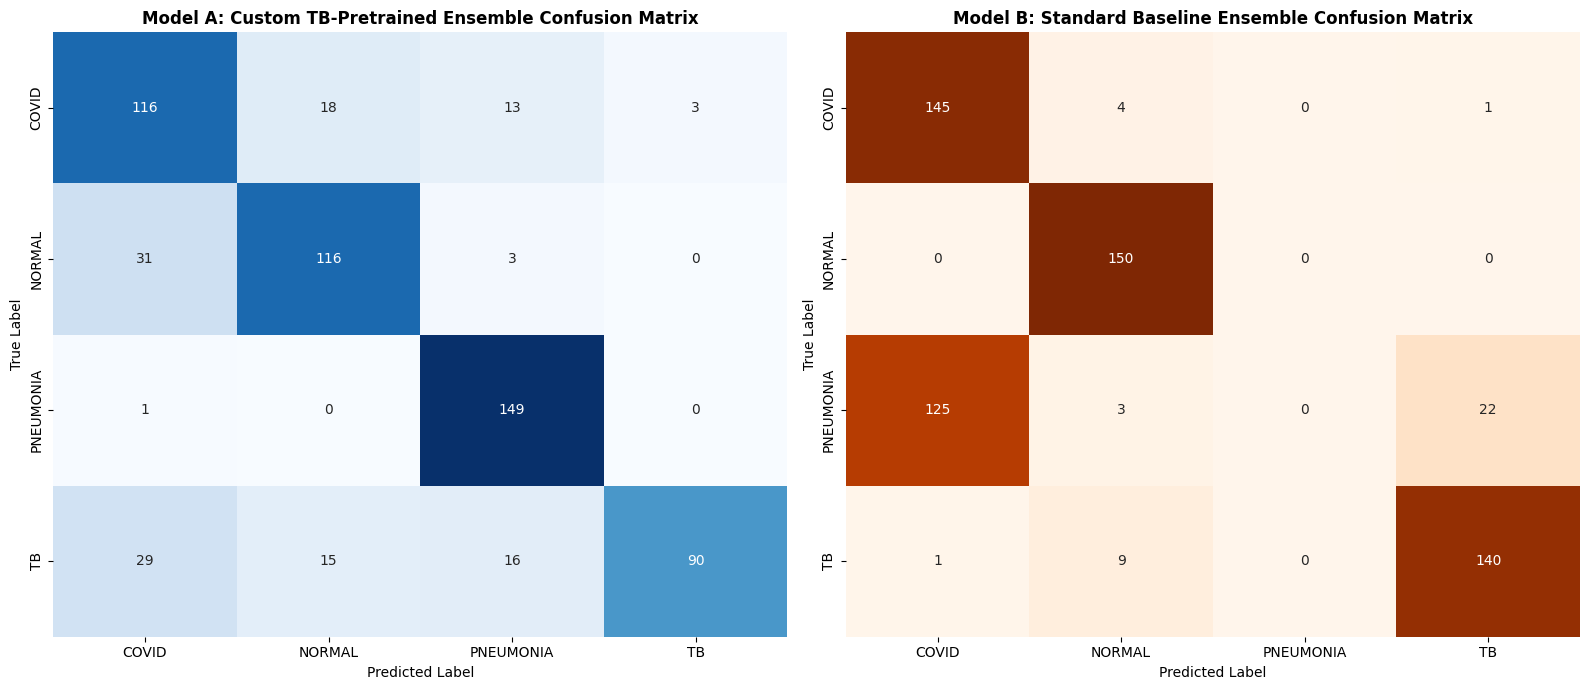


             FINAL TEST REPORT: MODEL A (PRETRAINED)
              precision    recall  f1-score   support

       COVID     0.6554    0.7733    0.7095       150
      NORMAL     0.7785    0.7733    0.7759       150
   PNEUMONIA     0.8232    0.9933    0.9003       150
          TB     0.9677    0.6000    0.7407       150

    accuracy                         0.7850       600
   macro avg     0.8062    0.7850    0.7816       600
weighted avg     0.8062    0.7850    0.7816       600


             FINAL TEST REPORT: MODEL B (BASELINE)
              precision    recall  f1-score   support

       COVID     0.5351    0.9667    0.6888       150
      NORMAL     0.9036    1.0000    0.9494       150
   PNEUMONIA     0.0000    0.0000    0.0000       150
          TB     0.8589    0.9333    0.8946       150

    accuracy                         0.7250       600
   macro avg     0.5744    0.7250    0.6332       600
weighted avg     0.5744    0.7250    0.6332       600



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


In [4]:
# --- 1. Configurations ---
# Point this exactly to your independent test folder location
KANO_TEST_DIR = "/kaggle/input/datasets/spark2026nc/cxr-kano/cxr-kano/test_folder" 
BATCH_SIZE = 32
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# --- 2. Simple Test Dataset Parser ---
class KanoTestDataset(Dataset):
    def __init__(self, base_dir, transform=None):
        self.base_dir = base_dir
        self.transform = transform
        self.image_data = []
        self.class_names = ["COVID", "NORMAL", "PNEUMONIA", "TB"]
        
        for label_idx, class_name in enumerate(self.class_names):
            class_folder = os.path.join(base_dir, class_name)
            images = sorted(glob.glob(os.path.join(class_folder, "*.png")) + 
                            glob.glob(os.path.join(class_folder, "*.jpg")) + 
                            glob.glob(os.path.join(class_folder, "*.jpeg")))
            for img_path in images:
                self.image_data.append((img_path, label_idx))
                
    def __len__(self):
        return len(self.image_data)

    def __getitem__(self, idx):
        img_path, label = self.image_data[idx]
        image = Image.open(img_path).convert("RGB")
        if self.transform:
            image = self.transform(image)
        return image, torch.tensor(label, dtype=torch.long)

# --- 3. Test Transform Pipeline (No Augmentation) ---
test_transforms = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

# --- 4. Prediction Extraction Function (5-Fold Ensemble) ---
def get_ensemble_predictions(checkpoint_prefix, test_loader, num_classes=4, is_phase1_pretrained=False):
    all_preds_probs = []
    true_labels = []
    
    # Store all images and true labels once
    for images, labels in test_loader:
        true_labels.extend(labels.numpy())
    true_labels = np.array(true_labels)
    
    # Accumulate probabilities across all 5 saved fold checkpoints
    ensemble_probs = np.zeros((len(test_loader.dataset), num_classes))
    
    print(f"\nExtracting ensemble predictions for weights matching: {checkpoint_prefix}*")
    
    for fold in range(1, 6):
        checkpoint_path = f"{checkpoint_prefix}_fold{fold}.pth"
        
        # Initialize bare model architecture
        model = densenet121(weights=None)
        
        if is_phase1_pretrained:
            # Match the structural swapping logic used during Model A training
            model.classifier = nn.Linear(model.classifier.in_features, 2)
            model.classifier = nn.Linear(model.classifier.in_features, 4)
        else:
            model.classifier = nn.Linear(model.classifier.in_features, 4)
            
        if os.path.exists(checkpoint_path):
            model.load_state_dict(torch.load(checkpoint_path, map_location=DEVICE))
            model = model.to(DEVICE)
            model.eval()
            
            fold_probs = []
            with torch.no_grad():
                for images, _ in test_loader:
                    images = images.to(DEVICE)
                    outputs = model(images)
                    probs = torch.softmax(outputs, dim=1)
                    fold_probs.extend(probs.cpu().numpy())
            
            ensemble_probs += np.array(fold_probs)
            print(f"  -> Successfully compiled probabilities from Fold {fold}")
        else:
            print(f"  ->  Checkpoint missing: {checkpoint_path}. Skipping this fold.")
            
    # Take average probability across the folds
    ensemble_probs /= 5.0
    final_predictions = np.argmax(ensemble_probs, axis=1)
    return true_labels, final_predictions

# --- 5. Main Execution Block ---
def evaluate_on_test_set():
    test_dataset = KanoTestDataset(KANO_TEST_DIR, transform=test_transforms)
    test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=4)
    
    print(f"Total isolated test samples located: {len(test_dataset)} images")
    
    # Get predictions for Model A (Custom Pretrained Stream)
    y_true, y_pred_a = get_ensemble_predictions(
        checkpoint_prefix="kano_finetuned", 
        test_loader=test_loader, 
        is_phase1_pretrained=True
    )
    
    # Get predictions for Model B (Standard Baseline Stream)
    _, y_pred_b = get_ensemble_predictions(
        checkpoint_prefix="kano_baseline", 
        test_loader=test_loader, 
        is_phase1_pretrained=False
    )
    
    # --- 6. Plotting the Real Confusion Matrices ---
    class_names = ["COVID", "NORMAL", "PNEUMONIA", "TB"]
    fig, axes = plt.subplots(1, 2, figsize=(16, 7))
    
    # Model A Plot
    cm_a = confusion_matrix(y_true, y_pred_a)
    sns.heatmap(cm_a, annot=True, fmt='d', cmap='Blues', xticklabels=class_names, yticklabels=class_names, ax=axes[0], cbar=False)
    axes[0].set_title("Model A: Custom TB-Pretrained Ensemble Confusion Matrix", fontsize=12, fontweight='bold')
    axes[0].set_xlabel("Predicted Label")
    axes[0].set_ylabel("True Label")
    
    # Model B Plot
    cm_b = confusion_matrix(y_true, y_pred_b)
    sns.heatmap(cm_b, annot=True, fmt='d', cmap='Oranges', xticklabels=class_names, yticklabels=class_names, ax=axes[1], cbar=False)
    axes[1].set_title("Model B: Standard Baseline Ensemble Confusion Matrix", fontsize=12, fontweight='bold')
    axes[1].set_xlabel("Predicted Label")
    axes[1].set_ylabel("True Label")
    
    plt.tight_layout()
    plt.savefig("final_test_set_comparison.png", dpi=300)
    plt.show()
    
    # --- 7. Print Performance Reports ---
    print("\n" + "="*60)
    print("             FINAL TEST REPORT: MODEL A (PRETRAINED)")
    print("="*60)
    print(classification_report(y_true, y_pred_a, target_names=class_names, digits=4))
    
    print("\n" + "="*60)
    print("             FINAL TEST REPORT: MODEL B (BASELINE)")
    print("="*60)
    print(classification_report(y_true, y_pred_b, target_names=class_names, digits=4))

if __name__ == "__main__":
    evaluate_on_test_set()

## Evaluating the newly Optimized model 


Gathering ensemble probabilities for: kano_optimized*
  -> Successfully integrated Fold 1
  -> Successfully integrated Fold 2
  -> Successfully integrated Fold 3
  -> Successfully integrated Fold 4
  -> Successfully integrated Fold 5

Gathering ensemble probabilities for: kano_baseline_optimized*
  -> Successfully integrated Fold 1
  -> Successfully integrated Fold 2
  -> Successfully integrated Fold 3
  -> Successfully integrated Fold 4
  -> Successfully integrated Fold 5


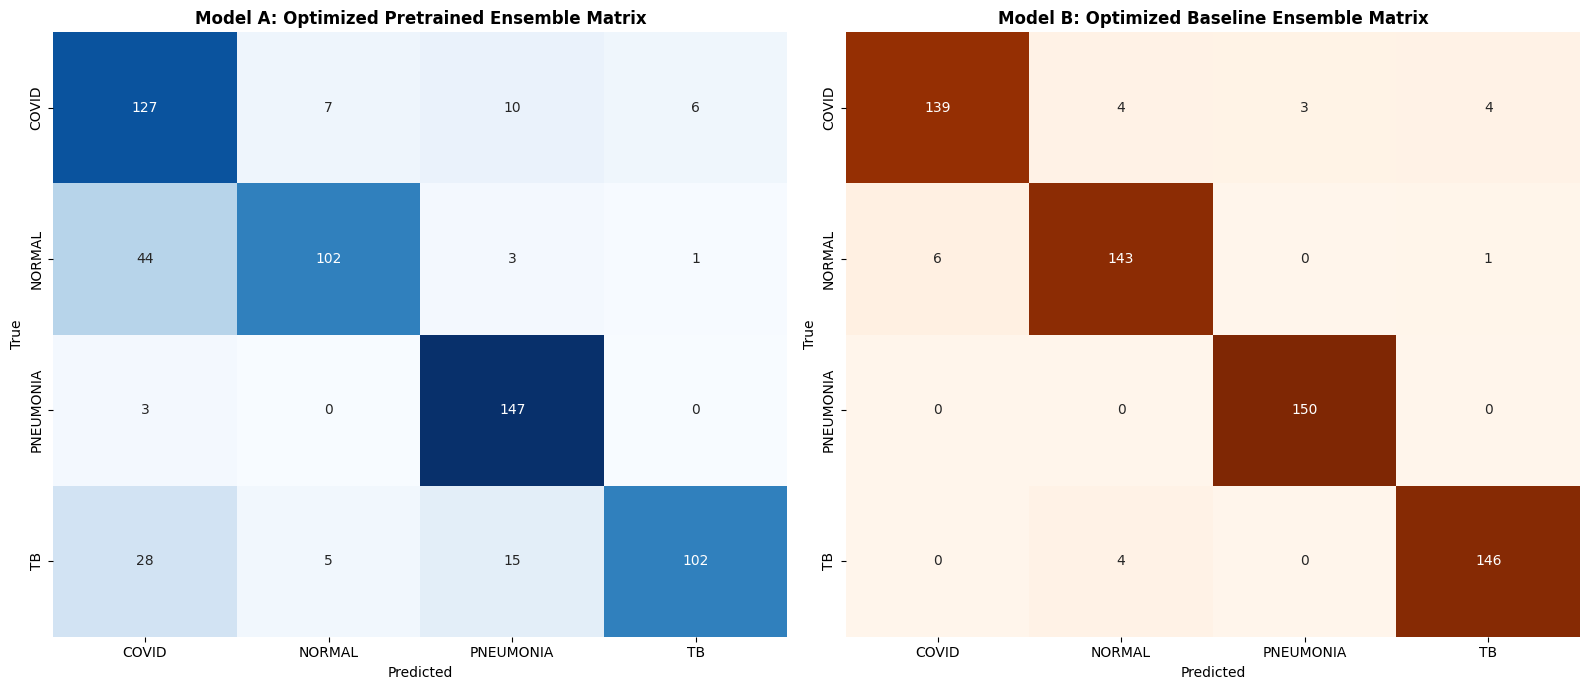


📊 MULTI-CLASS PERFORMANCE REPORT: OPTIMIZED MODEL A
              precision    recall  f1-score   support

       COVID     0.6287    0.8467    0.7216       150
      NORMAL     0.8947    0.6800    0.7727       150
   PNEUMONIA     0.8400    0.9800    0.9046       150
          TB     0.9358    0.6800    0.7876       150

    accuracy                         0.7967       600
   macro avg     0.8248    0.7967    0.7966       600
weighted avg     0.8248    0.7967    0.7966       600


📊 MULTI-CLASS PERFORMANCE REPORT: OPTIMIZED MODEL B
              precision    recall  f1-score   support

       COVID     0.9586    0.9267    0.9424       150
      NORMAL     0.9470    0.9533    0.9502       150
   PNEUMONIA     0.9804    1.0000    0.9901       150
          TB     0.9669    0.9733    0.9701       150

    accuracy                         0.9633       600
   macro avg     0.9632    0.9633    0.9632       600
weighted avg     0.9632    0.9633    0.9632       600



In [4]:
import os
import glob
import numpy as np
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
import torchvision.transforms as transforms
from torchvision.models import densenet121
from PIL import Image
import matplotlib.pyplot as plt
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns

# --- 1. Configurations ---
KANO_TEST_DIR = "/kaggle/input/datasets/spark2026nc/cxr-kano/cxr-kano/test_folder" 
BATCH_SIZE = 32
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# --- 2. Test Dataset Parser ---
class KanoTestDataset(Dataset):
    def __init__(self, base_dir, transform=None):
        self.base_dir = base_dir
        self.transform = transform
        self.image_data = []
        self.class_names = ["COVID", "NORMAL", "PNEUMONIA", "TB"]
        
        for label_idx, class_name in enumerate(self.class_names):
            class_folder = os.path.join(base_dir, class_name)
            images = sorted(glob.glob(os.path.join(class_folder, "*.png")) + 
                            glob.glob(os.path.join(class_folder, "*.jpg")) + 
                            glob.glob(os.path.join(class_folder, "*.jpeg")))
            for img_path in images:
                self.image_data.append((img_path, label_idx))
                
    def __len__(self):
        return len(self.image_data)

    def __getitem__(self, idx):
        img_path, label = self.image_data[idx]
        image = Image.open(img_path).convert("RGB")
        if self.transform:
            image = self.transform(image)
        return image, torch.tensor(label, dtype=torch.long)

test_transforms = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

# --- 3. Ensemble Prediction Engine ---
def get_ensemble_predictions(checkpoint_prefix, test_loader, is_phase1_pretrained=False):
    true_labels = []
    for _, labels in test_loader:
        true_labels.extend(labels.numpy())
    true_labels = np.array(true_labels)
    
    ensemble_probs = np.zeros((len(test_loader.dataset), 4))
    print(f"\nGathering ensemble probabilities for: {checkpoint_prefix}*")
    
    for fold in range(1, 6):
        checkpoint_path = f"{checkpoint_prefix}_fold{fold}.pth"
        model = densenet121(weights=None)
        
        if is_phase1_pretrained:
            model.classifier = nn.Linear(model.classifier.in_features, 2)
            model.classifier = nn.Linear(model.classifier.in_features, 4)
        else:
            model.classifier = nn.Linear(model.classifier.in_features, 4)
            
        if os.path.exists(checkpoint_path):
            model.load_state_dict(torch.load(checkpoint_path, map_location=DEVICE))
            model = model.to(DEVICE).eval()
            
            fold_probs = []
            with torch.no_grad():
                for images, _ in test_loader:
                    outputs = model(images.to(DEVICE))
                    probs = torch.softmax(outputs, dim=1)
                    fold_probs.extend(probs.cpu().numpy())
            ensemble_probs += np.array(fold_probs)
            print(f"  -> Successfully integrated Fold {fold}")
        else:
            print(f"  -> ⚠️ Missing checkpoint: {checkpoint_path}")
            
    return true_labels, np.argmax(ensemble_probs / 5.0, axis=1)

# --- 4. Execution & Visualization ---
if __name__ == "__main__":
    test_dataset = KanoTestDataset(KANO_TEST_DIR, transform=test_transforms)
    test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=4)
    
    # 1. Load your optimized pretrained model (Model A)
    y_true, y_pred_opt_a = get_ensemble_predictions("kano_optimized", test_loader, is_phase1_pretrained=True)
    
    # 2. Load your newly optimized baseline model (Model B)
    _, y_pred_opt_b = get_ensemble_predictions("kano_baseline_optimized", test_loader, is_phase1_pretrained=False)
    
    # Plot Side-by-Side Confusion Matrices
    class_names = ["COVID", "NORMAL", "PNEUMONIA", "TB"]
    fig, axes = plt.subplots(1, 2, figsize=(16, 7))
    
    sns.heatmap(confusion_matrix(y_true, y_pred_opt_a), annot=True, fmt='d', cmap='Blues', xticklabels=class_names, yticklabels=class_names, ax=axes[0], cbar=False)
    axes[0].set_title("Model A: Optimized Pretrained Ensemble Matrix", fontsize=12, fontweight='bold')
    axes[0].set_xlabel("Predicted")
    axes[0].set_ylabel("True")
    
    sns.heatmap(confusion_matrix(y_true, y_pred_opt_b), annot=True, fmt='d', cmap='Oranges', xticklabels=class_names, yticklabels=class_names, ax=axes[1], cbar=False)
    axes[1].set_title("Model B: Optimized Baseline Ensemble Matrix", fontsize=12, fontweight='bold')
    axes[1].set_xlabel("Predicted")
    axes[1].set_ylabel("True")
    
    plt.tight_layout()
    plt.savefig("optimized_test_comparison.png", dpi=300)
    plt.show()
    
    print("\n📊 MULTI-CLASS PERFORMANCE REPORT: OPTIMIZED MODEL A")
    print(classification_report(y_true, y_pred_opt_a, target_names=class_names, digits=4))
    
    print("\n📊 MULTI-CLASS PERFORMANCE REPORT: OPTIMIZED MODEL B")
    print(classification_report(y_true, y_pred_opt_b, target_names=class_names, digits=4))